# Credit Card Default Prediction with LSTM

This notebook uses a **Long Short-Term Memory (LSTM)** neural network to predict whether a credit card client will default on their next payment.

**LSTM framing:** Each client has 6 months of temporal data (April–September 2005):
- Payment repayment status (`X6`–`X11`)
- Bill statement amounts (`X12`–`X17`)  
- Previous payment amounts (`X18`–`X23`)

These form a **6-timestep sequence** per client, which the LSTM processes to predict October default (`y`).

**Changes from baseline:**
- **Feature engineering**: Additional temporal features are derived from the raw data — utilization ratio, payment-to-bill ratio, binary delay flags, and month-over-month changes. This gives the LSTM 8 features per timestep instead of 3.
- **Engineered static features**: Summary statistics (max delay severity, number of delinquent months, average utilization) and one-hot encoded categorical features are added.
- **Class weighting**: With only ~22% of customers defaulting, inverse-frequency class weights are applied during training to prevent the model from collapsing to the majority class.

In [115]:
# Install required packages if not already present.
# ucimlrepo fetches the dataset directly from UCI; shap is available for interpretability.
import subprocess, sys
pkgs = ['ucimlrepo', 'tensorflow', 'scikit-learn', 'matplotlib', 'seaborn', 'pandas', 'numpy', 'shap']
for pkg in pkgs:
    try:
        __import__(pkg.replace('-','_'))
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All packages ready.')

All packages ready.


In [116]:
# Consolidate all imports here to surface missing-dependency errors early.

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from ucimlrepo import fetch_ucirepo

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    accuracy_score, f1_score, matthews_corrcoef, brier_score_loss,
    precision_score, recall_score
)
from sklearn.calibration import calibration_curve

# Pin seeds for reproducibility across runs (note: GPU non-determinism may cause minor variance)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

---
## 1. Load Data

In [117]:
# Fetch dataset directly from UCI ML Repository (ID 350 = Default of Credit Card Clients).
# This avoids a dependency on a local file and ensures the canonical version is used.

dataset = fetch_ucirepo(id=350)

X_raw = dataset.data.features.copy()
y_raw = dataset.data.targets.copy()

# Map generic API column names (X1-X23) back to the documented feature names.
feature_names = {
    'X1': 'LIMIT_BAL', 'X2': 'SEX', 'X3': 'EDUCATION', 'X4': 'MARRIAGE', 'X5': 'AGE',
    'X6': 'PAY_0', 'X7': 'PAY_2', 'X8': 'PAY_3', 'X9': 'PAY_4', 'X10': 'PAY_5', 'X11': 'PAY_6',
    'X12': 'BILL_AMT1', 'X13': 'BILL_AMT2', 'X14': 'BILL_AMT3',
    'X15': 'BILL_AMT4', 'X16': 'BILL_AMT5', 'X17': 'BILL_AMT6',
    'X18': 'PAY_AMT1', 'X19': 'PAY_AMT2', 'X20': 'PAY_AMT3',
    'X21': 'PAY_AMT4', 'X22': 'PAY_AMT5', 'X23': 'PAY_AMT6',
}
X_raw = X_raw.rename(columns=feature_names)

if isinstance(y_raw, pd.DataFrame):
    y_raw = y_raw.iloc[:, 0]
y_raw.name = 'default'

df = X_raw.copy()
df['default'] = y_raw.values

print(f'Dataset shape: {df.shape}')
print(f'\nDefault rate: {df["default"].mean():.2%}')
df.head()

Dataset shape: (30000, 24)

Default rate: 22.12%


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


---
## 2. Exploratory Data Analysis

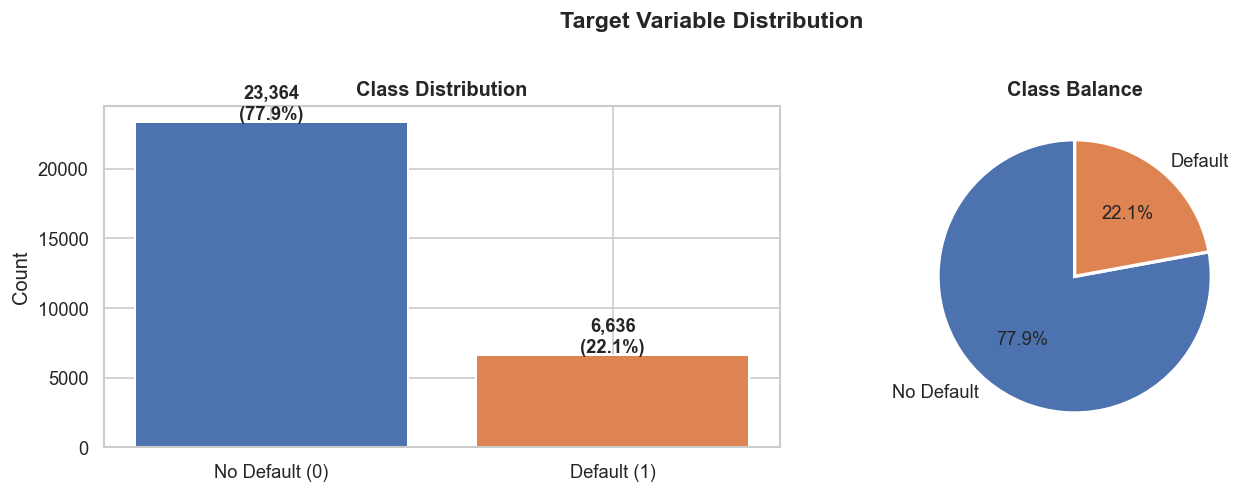

In [118]:
# --- 2.1 Class Distribution ---
# Visualise the class imbalance. With ~22% defaults, a naive model predicting
# 'no default' for every customer would achieve 78% accuracy — class weighting
# and appropriate metrics (F1, MCC) are therefore essential.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['default'].value_counts()
axes[0].bar(['No Default (0)', 'Default (1)'], counts.values, color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=1.2)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df):.1%})', ha='center', fontweight='bold')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=['No Default', 'Default'],
            colors=['#4C72B0', '#DD8452'], autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Balance', fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

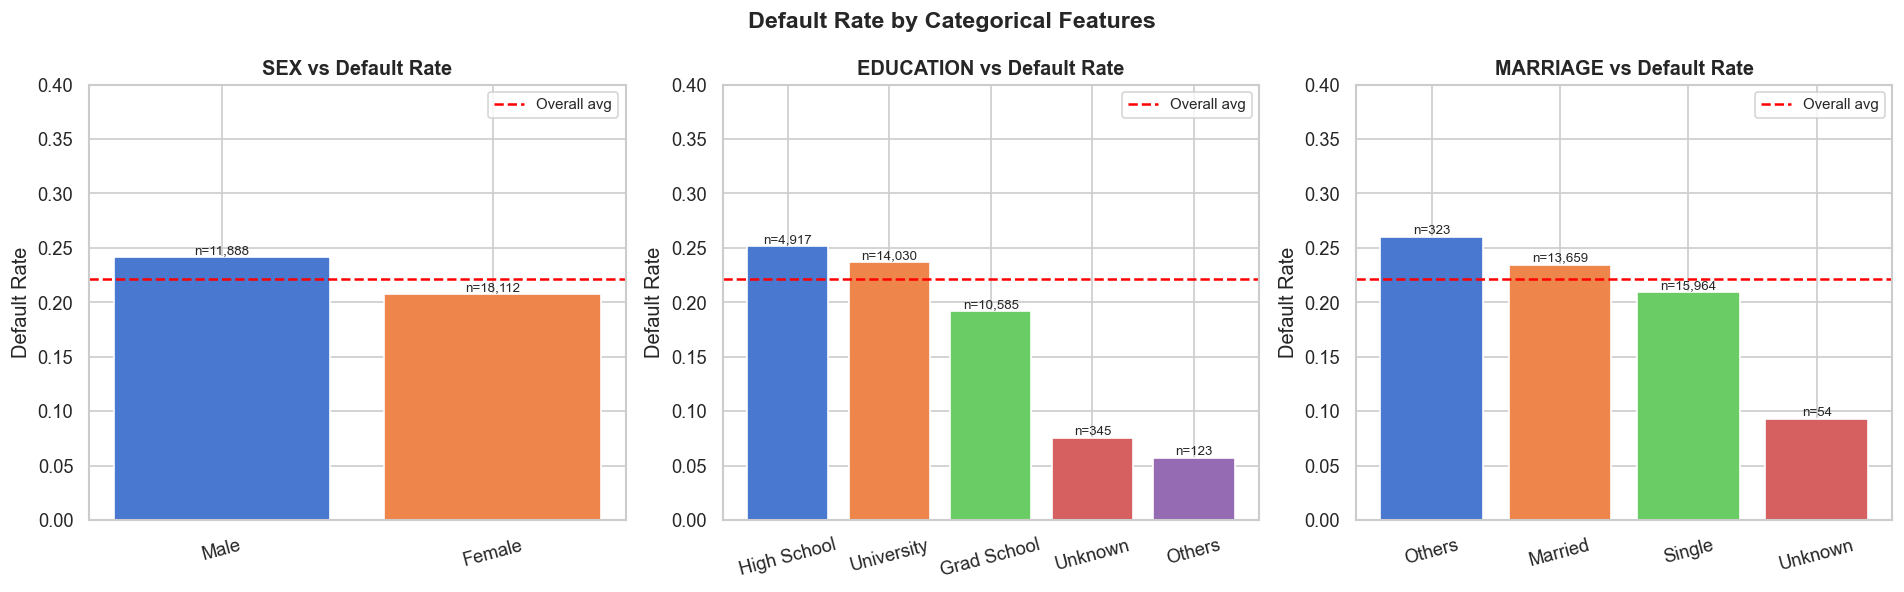

In [119]:
# --- 2.2 Categorical Feature vs Default Rate ---
# Check whether gender, education level, or marital status correlate with
# default rates. The red dashed line marks the overall average default rate (~22%).

cat_cols = {
    'SEX': {1: 'Male', 2: 'Female'},
    'EDUCATION': {1: 'Grad School', 2: 'University', 3: 'High School', 4: 'Others', 0: 'Unknown', 5: 'Unknown', 6: 'Unknown'},
    'MARRIAGE': {0: 'Unknown', 1: 'Married', 2: 'Single', 3: 'Others'}
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, label_map) in zip(axes, cat_cols.items()):
    mapped = df[col].map(label_map).fillna('Unknown')
    dr = df.groupby(mapped)['default'].agg(['mean', 'count']).reset_index()
    dr.columns = ['Category', 'Default Rate', 'Count']
    dr = dr.sort_values('Default Rate', ascending=False)

    bars = ax.bar(dr['Category'], dr['Default Rate'], color=sns.color_palette('muted', len(dr)), edgecolor='white')
    for bar, cnt in zip(bars, dr['Count']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'n={cnt:,}', ha='center', fontsize=8)
    ax.axhline(df['default'].mean(), color='red', linestyle='--', linewidth=1.5, label='Overall avg')
    ax.set_title(f'{col} vs Default Rate', fontweight='bold')
    ax.set_ylabel('Default Rate')
    ax.set_ylim(0, 0.40)
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Default Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

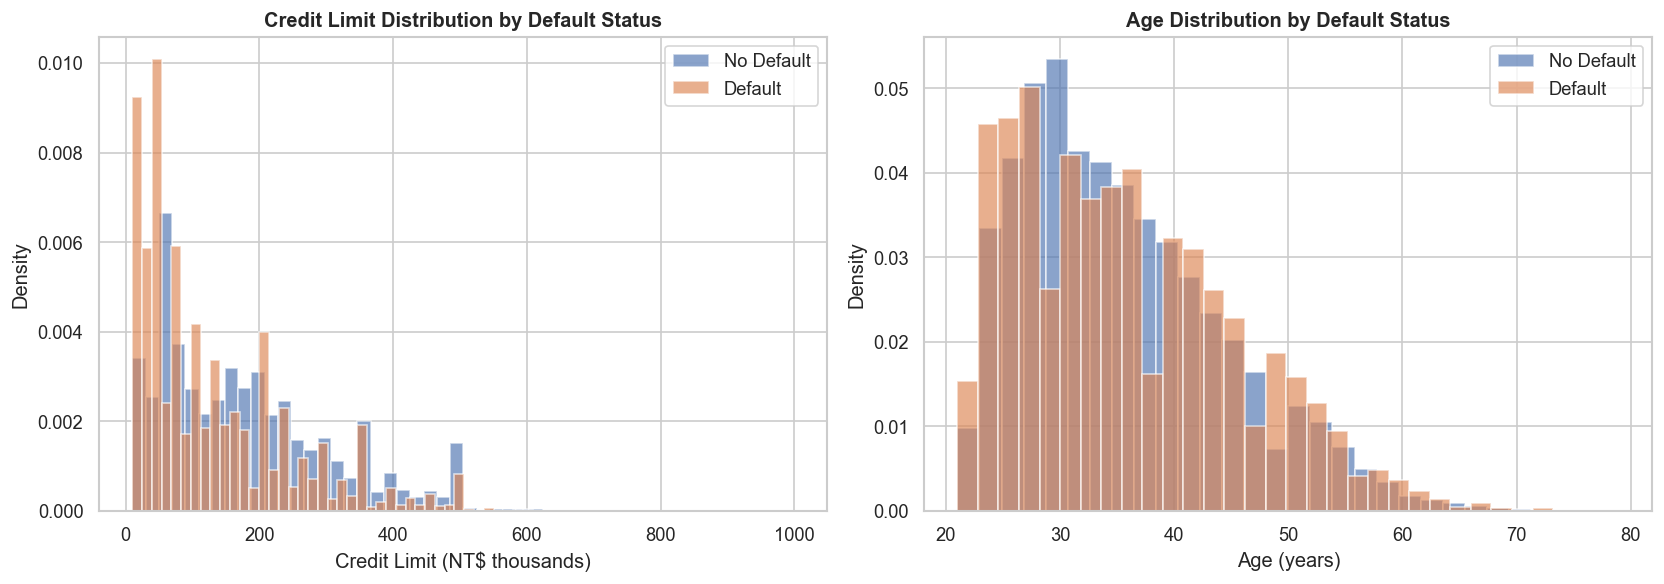

In [120]:
# --- 2.3 Credit Limit and Age distributions by default status ---
# Compare distributions for defaulters vs non-defaulters. Good separation
# indicates a useful predictive feature. Lower credit limits are expected to
# correlate with higher default risk, as banks assign lower limits to riskier customers.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, grp in df.groupby('default'):
    name = 'Default' if label == 1 else 'No Default'
    color = '#DD8452' if label == 1 else '#4C72B0'
    axes[0].hist(grp['LIMIT_BAL'] / 1000, bins=50, alpha=0.65, label=name, color=color, density=True)
    axes[1].hist(grp['AGE'], bins=30, alpha=0.65, label=name, color=color, density=True)

axes[0].set_xlabel('Credit Limit (NT$ thousands)')
axes[0].set_title('Credit Limit Distribution by Default Status', fontweight='bold')
axes[0].legend()
axes[1].set_xlabel('Age (years)')
axes[1].set_title('Age Distribution by Default Status', fontweight='bold')
axes[1].legend()

for ax in axes:
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

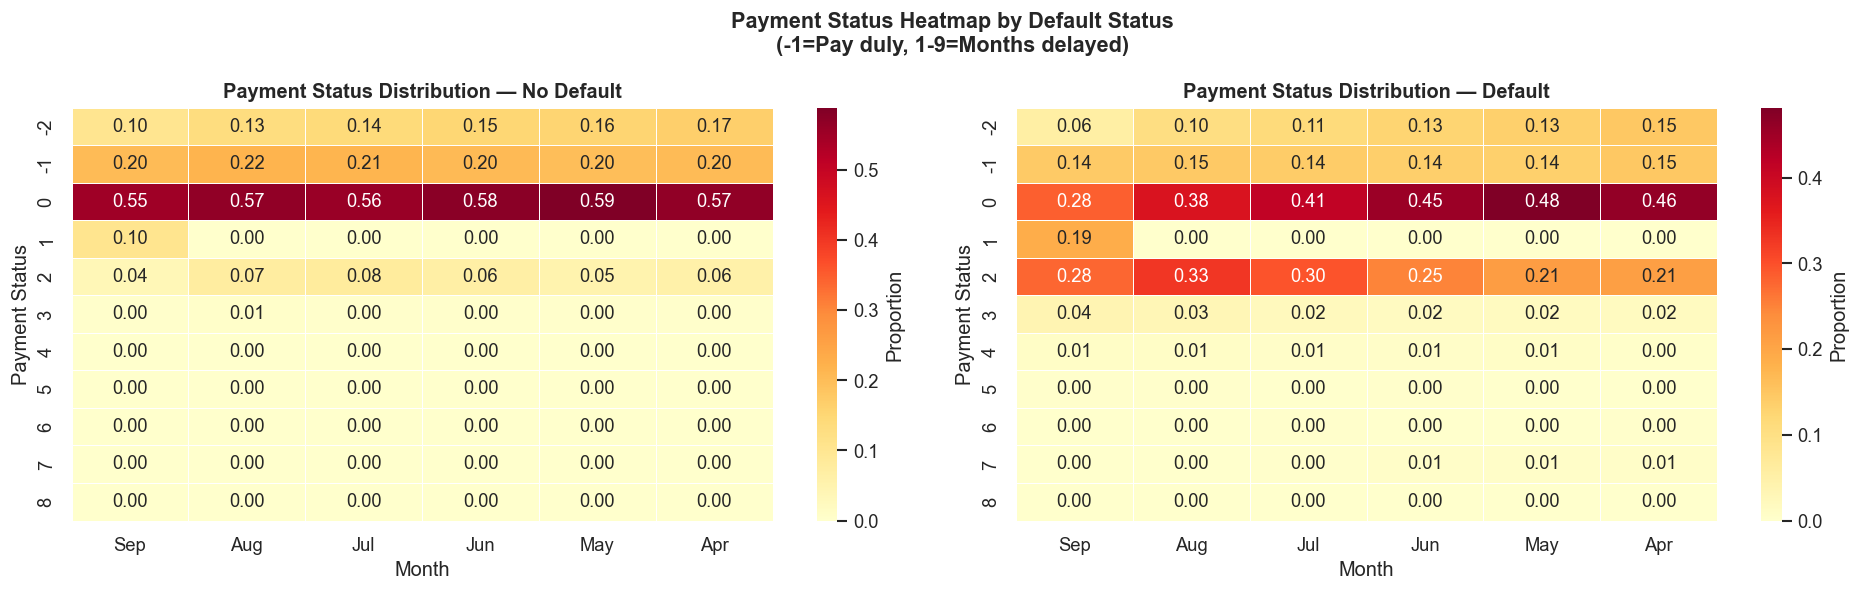

In [121]:
# --- 2.4 Payment status heatmaps ---
# Distribution of payment delay codes across all 6 months, split by default status.
# Persistent high delay codes (2+ months late) in the defaulter group represent
# the primary temporal pattern the LSTM is designed to capture.

pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
months   = ['Sep', 'Aug', 'Jul', 'Jun', 'May', 'Apr']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (label, grp) in zip(axes, df.groupby('default')):
    pay_dist = grp[pay_cols].apply(lambda x: x.value_counts(normalize=True)).fillna(0)
    pay_dist.columns = months
    pay_dist = pay_dist.sort_index()
    sns.heatmap(pay_dist, ax=ax, annot=True, fmt='.2f', cmap='YlOrRd',
                linewidths=0.5, cbar_kws={'label': 'Proportion'})
    ax.set_title(f'Payment Status Distribution — {"Default" if label==1 else "No Default"}', fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Payment Status')

plt.suptitle('Payment Status Heatmap by Default Status\n(-1=Pay duly, 1-9=Months delayed)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

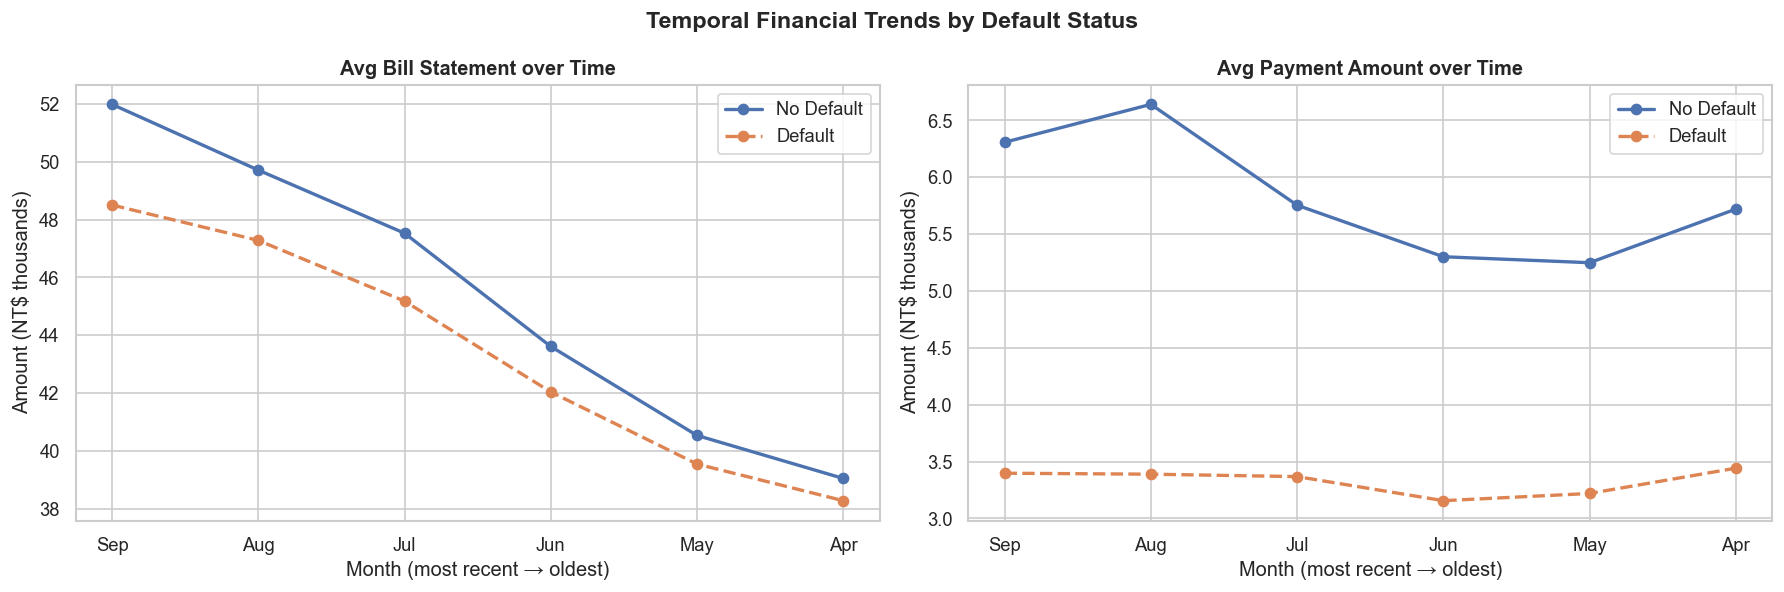

In [122]:
# --- 2.5 Temporal trends: avg bill and payment by default status ---
# Average bill and payment amounts over 6 months, grouped by default status.
# Defaulters are expected to carry higher bills relative to payments —
# an indication that balances are compounding rather than being paid down.

bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for label, grp in df.groupby('default'):
    name = 'Default' if label == 1 else 'No Default'
    color = '#DD8452' if label == 1 else '#4C72B0'
    ls    = '--' if label == 1 else '-'
    axes[0].plot(months, grp[bill_cols].mean().values / 1000, label=name, color=color, linestyle=ls, marker='o', linewidth=2)
    axes[1].plot(months, grp[pay_amt_cols].mean().values / 1000, label=name, color=color, linestyle=ls, marker='o', linewidth=2)

axes[0].set_title('Avg Bill Statement over Time', fontweight='bold')
axes[0].set_ylabel('Amount (NT$ thousands)')
axes[0].legend()
axes[1].set_title('Avg Payment Amount over Time', fontweight='bold')
axes[1].set_ylabel('Amount (NT$ thousands)')
axes[1].legend()

for ax in axes:
    ax.set_xlabel('Month (most recent → oldest)')

plt.suptitle('Temporal Financial Trends by Default Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

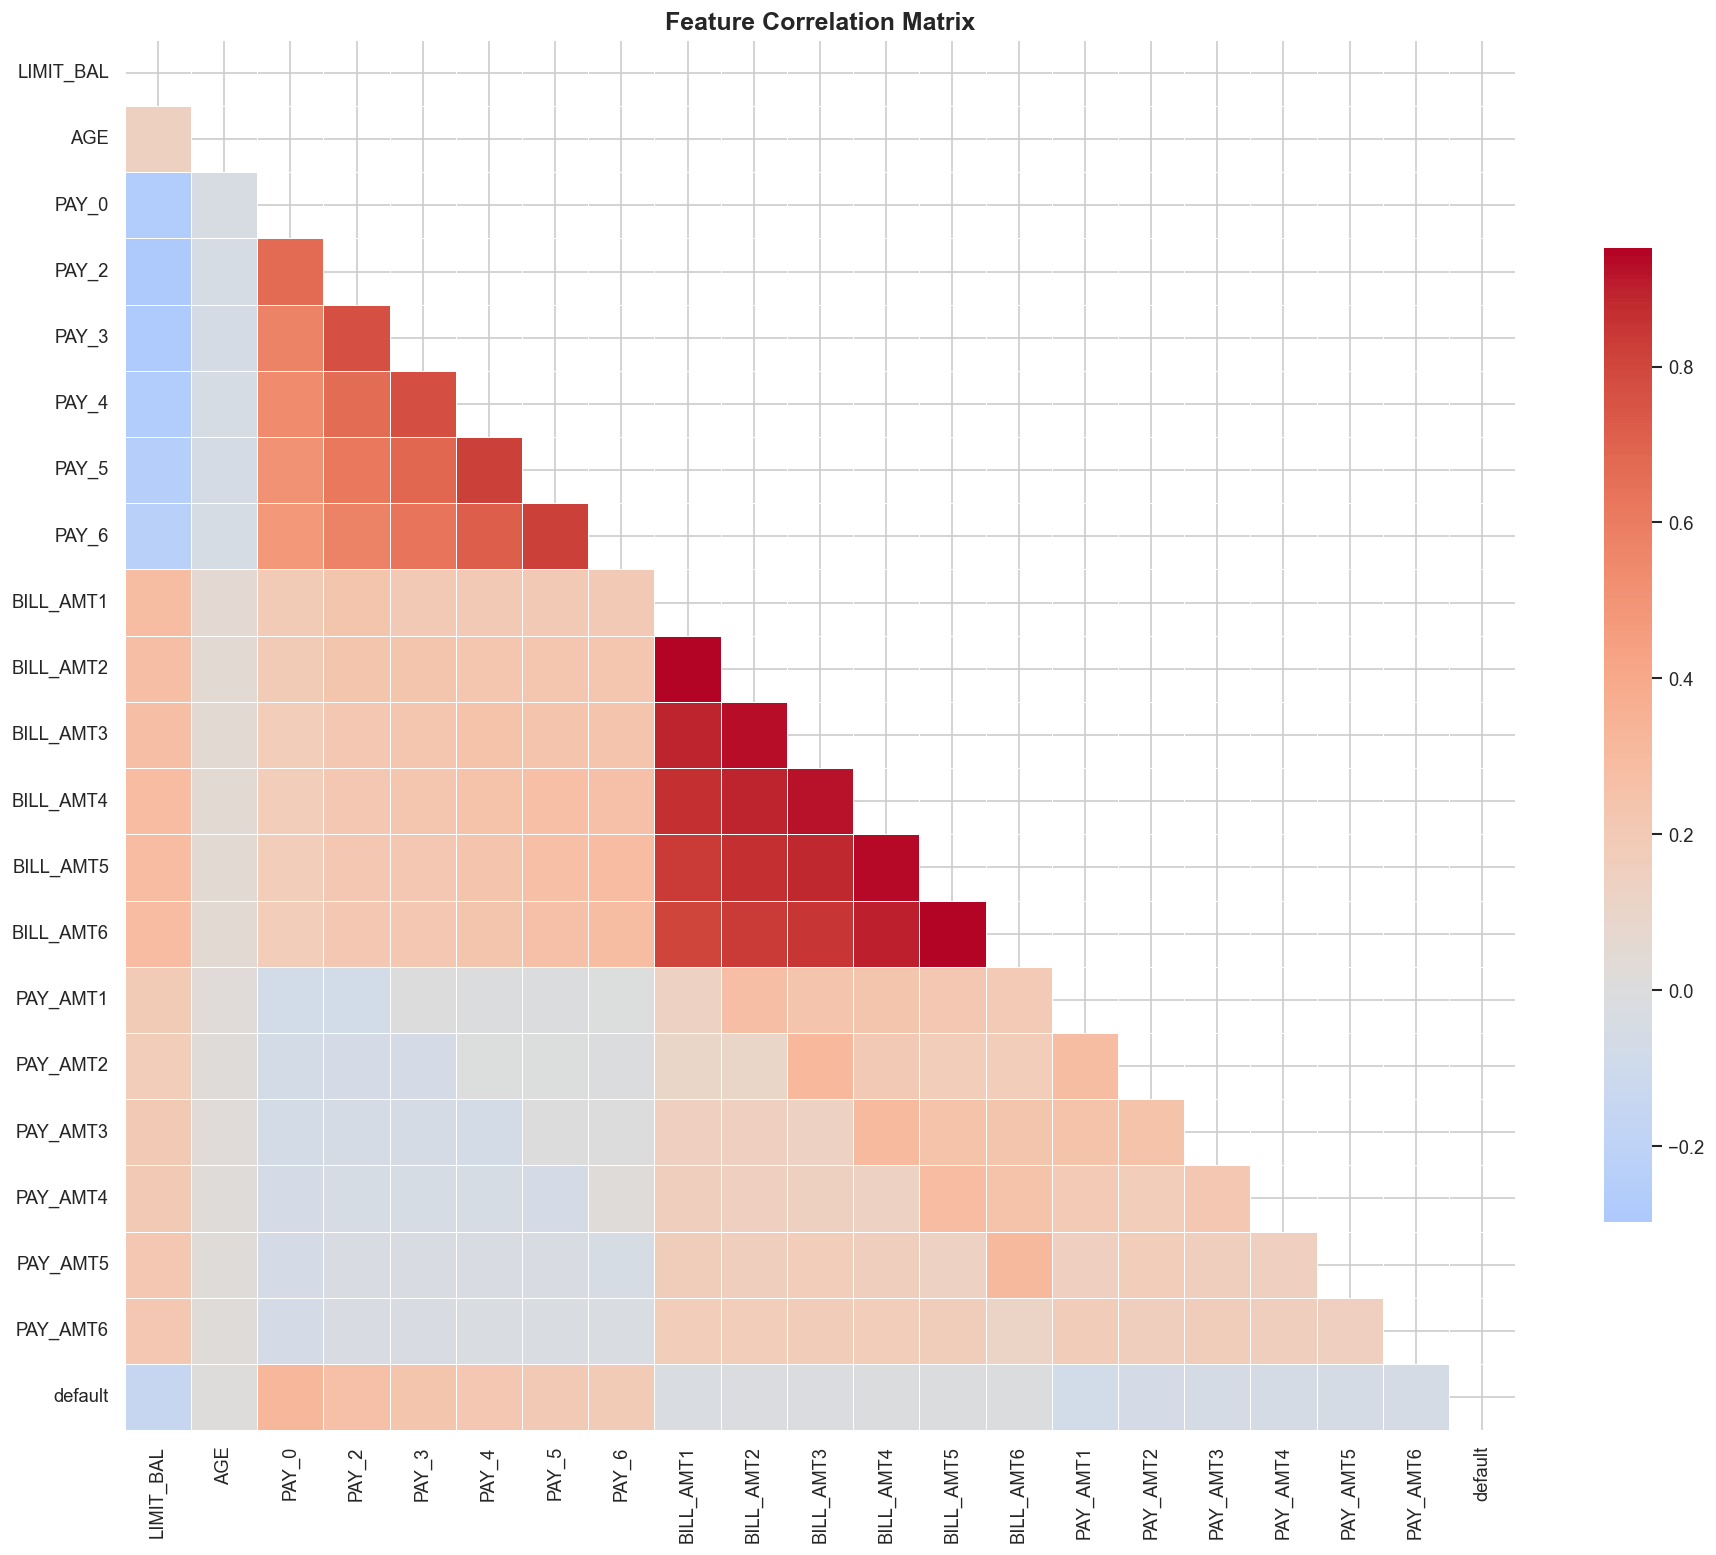

In [123]:
# --- 2.6 Correlation matrix ---
# Check for multicollinearity and feature-target correlations.
# The BILL_AMT columns are expected to be highly correlated with each other
# (monthly bills are autocorrelated), which motivates engineering the month-over-month
# change as a separate, less redundant feature.

corr_cols = ['LIMIT_BAL','AGE'] + pay_cols + bill_cols + pay_amt_cols + ['default']
corr = df[corr_cols].corr()

plt.figure(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, square=True,
            linewidths=0.3, annot=False, cbar_kws={'shrink': 0.7})
plt.title('Feature Correlation Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Data Preprocessing for LSTM

The data is reshaped into **6 timesteps × 8 temporal features** per client. The original dataset provides 3 raw features per month; 5 additional features are engineered from the existing data:

**Raw temporal features (3):**
- `pay_status` — repayment delay code (-2 to 8)
- `bill_amount` — monthly bill statement in NT$
- `pay_amount` — amount actually paid that month

**Engineered temporal features (5):**
- `utilization_ratio` — bill amount / credit limit. High utilization is a classic credit risk signal.
- `payment_ratio` — payment amount / bill amount. A ratio consistently below 1.0 means the balance is growing.
- `is_delayed` — binary flag: was the payment late at all? Simplifies the noisy -2..8 PAY scale.
- `bill_change` — month-over-month change in bill amount. Rising bills with flat payments signals accumulating debt.
- `pay_status_change` — month-over-month change in delay status. Deteriorating delay trend is among the strongest predictors.

**Static features (13 total):**
- LIMIT_BAL, SEX, AGE (raw demographics)
- One-hot encoded EDUCATION (4 categories) and MARRIAGE (3 categories) — treating these as ordinal numbers would imply a ranking that does not exist
- Max payment delay across all 6 months
- Number of months with any payment delay
- Average credit utilization ratio

The static features are concatenated with the LSTM output at the classification head.

In [124]:
# Normalise column names to uppercase to guard against capitalisation differences
# across UCI API versions.
df.columns = [c.upper() for c in df.columns]

# Some versions label September's payment status PAY_1 instead of PAY_0.
if 'PAY_0' not in df.columns and 'PAY_1' in df.columns:
    df = df.rename(columns={'PAY_1': 'PAY_0'})

# Verify all required columns are present before proceeding.
required = (['LIMIT_BAL','SEX','EDUCATION','MARRIAGE','AGE'] +
            [f'PAY_{i}' for i in [0,2,3,4,5,6]] +
            [f'BILL_AMT{i}' for i in range(1,7)] +
            [f'PAY_AMT{i}' for i in range(1,7)] +
            ['DEFAULT'])
missing = [c for c in required if c not in df.columns]
if missing:
    print('Missing columns:', missing)
else:
    print('All required columns present.')
print('Columns:', df.columns.tolist())

All required columns present.
Columns: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT']


In [125]:
# ── Temporal features (chronological order: Apr→Sep) ──────────────────────
# Months are ordered oldest→newest so the LSTM processes the natural time progression.
# LSTMs give more weight to later timesteps, so September (most recent) is placed last.

pay_status_cols  = ['PAY_6','PAY_5','PAY_4','PAY_3','PAY_2','PAY_0']    # Apr→Sep
bill_amt_cols    = ['BILL_AMT6','BILL_AMT5','BILL_AMT4','BILL_AMT3','BILL_AMT2','BILL_AMT1']
pay_amt_cols_ord = ['PAY_AMT6','PAY_AMT5','PAY_AMT4','PAY_AMT3','PAY_AMT2','PAY_AMT1']

# ── Raw temporal arrays ───────────────────────────────────────────────────
pay_status_arr = df[pay_status_cols].values.astype(np.float32)   # (N, 6)
bill_amt_arr   = df[bill_amt_cols].values.astype(np.float32)     # (N, 6)
pay_amt_arr    = df[pay_amt_cols_ord].values.astype(np.float32)  # (N, 6)

# ── Engineered temporal features ──────────────────────────────────────────
# Utilization ratio: fraction of credit limit used each month.
limit_bal = df['LIMIT_BAL'].values.astype(np.float32).reshape(-1, 1)
utilization_ratio = bill_amt_arr / np.maximum(limit_bal, 1.0)

# Payment-to-bill ratio: fraction of the statement balance actually paid.
payment_ratio = pay_amt_arr / np.maximum(np.abs(bill_amt_arr), 1.0)
payment_ratio = np.clip(payment_ratio, 0, 10)

# Binary delay indicator: whether the payment was late at all (PAY > 0).
is_delayed = (pay_status_arr > 0).astype(np.float32)

# Month-over-month bill change: rising bills with flat payments indicate accumulating debt.
bill_change = np.zeros_like(bill_amt_arr)
bill_change[:, 1:] = bill_amt_arr[:, 1:] - bill_amt_arr[:, :-1]

# Month-over-month payment status change: positive = worsening delay, negative = improving.
pay_status_change = np.zeros_like(pay_status_arr)
pay_status_change[:, 1:] = pay_status_arr[:, 1:] - pay_status_arr[:, :-1]

# Paid-in-full flag: 1 if payment this month >= bill amount this month.
# Clients who consistently pay in full are far less likely to default.
pay_full_flag = (pay_amt_arr >= np.abs(bill_amt_arr)).astype(np.float32)

# Net balance gap: how much of the bill was left unpaid each month (normalised by credit limit).
# A growing gap signals accumulating debt even when minimum payments are made.
net_balance_gap = np.clip(
    (bill_amt_arr - pay_amt_arr) / np.maximum(limit_bal, 1.0),
    -1.0, 10.0
).astype(np.float32)

# ── Stack into temporal tensor: (N, 6, 10) ────────────────────────────────
temporal = np.stack([
    pay_status_arr,       # 1. raw delay code
    bill_amt_arr,         # 2. raw bill amount
    pay_amt_arr,          # 3. raw payment amount
    utilization_ratio,    # 4. bill / credit limit
    payment_ratio,        # 5. payment / bill
    is_delayed,           # 6. binary: was payment late?
    bill_change,          # 7. month-over-month bill delta
    pay_status_change,    # 8. month-over-month delay change
    pay_full_flag,        # 9. paid full balance this month?
    net_balance_gap,      # 10. unpaid gap normalised by credit limit
], axis=-1).astype(np.float32)

# ── Static features (with engineering) ─────────────────────────────────────
max_delay = pay_status_arr.max(axis=1).reshape(-1, 1)
num_delayed = is_delayed.sum(axis=1).reshape(-1, 1)
avg_utilization = utilization_ratio.mean(axis=1).reshape(-1, 1)

# Most recent delay status (September / PAY_0): single strongest individual predictor.
most_recent_delay = pay_status_arr[:, -1].reshape(-1, 1)

# Trend slope of payment status: positive = worsening over 6 months, negative = improving.
# Fit a 1D linear regression over the 6-timestep pay_status sequence per client.
months_norm = np.linspace(-1, 1, 6, dtype=np.float32)  # normalised time axis
pay_status_centered = pay_status_arr - pay_status_arr.mean(axis=1, keepdims=True)
trend_slope = (pay_status_centered * months_norm).sum(axis=1) / (months_norm ** 2).sum()
trend_slope = trend_slope.reshape(-1, 1).astype(np.float32)

# Overall payment coverage: sum of all payments / sum of all bills.
# Below 1.0 = revolving balance grew over the 6-month window.
total_bill   = np.abs(bill_amt_arr).sum(axis=1)
total_pay    = pay_amt_arr.sum(axis=1)
total_pay_ratio = np.clip(total_pay / np.maximum(total_bill, 1.0), 0, 5).reshape(-1, 1).astype(np.float32)

# Flag: any month with PAY >= 2 (seriously delinquent, 2+ months late).
has_serious_delay = (pay_status_arr >= 2).any(axis=1).astype(np.float32).reshape(-1, 1)

# One-hot encode EDUCATION and MARRIAGE
edu = df['EDUCATION'].values
edu_clean = np.where((edu < 1) | (edu > 4), 4, edu)
edu_onehot = np.zeros((len(edu), 4), dtype=np.float32)
for i in range(4):
    edu_onehot[:, i] = (edu_clean == (i + 1)).astype(np.float32)

mar = df['MARRIAGE'].values
mar_clean = np.where((mar < 1) | (mar > 3), 3, mar)
mar_onehot = np.zeros((len(mar), 3), dtype=np.float32)
for i in range(3):
    mar_onehot[:, i] = (mar_clean == (i + 1)).astype(np.float32)

# Final static feature vector: 3 raw + 4 edu + 3 mar + 3 original engineered
#   + 4 new engineered = 17 features total
static = np.hstack([
    df[['LIMIT_BAL', 'SEX', 'AGE']].values.astype(np.float32),  # 3
    edu_onehot,                                                   # 4
    mar_onehot,                                                   # 3
    max_delay,                                                    # 1
    num_delayed,                                                  # 1
    avg_utilization,                                              # 1
    most_recent_delay,                                            # 1
    trend_slope,                                                  # 1
    total_pay_ratio,                                              # 1
    has_serious_delay,                                            # 1
]).astype(np.float32)

target_col = 'DEFAULT'
y = df[target_col].values.astype(np.float32)

N_TEMPORAL_FEATURES = temporal.shape[2]
N_STATIC_FEATURES   = static.shape[1]

print(f'Temporal shape : {temporal.shape}  (samples, timesteps, features)')
print(f'Static shape   : {static.shape}   (samples, features)')
print(f'Target shape   : {y.shape}')
print(f'Temporal features per timestep: {N_TEMPORAL_FEATURES}')
print(f'Static features: {N_STATIC_FEATURES}')


Temporal shape : (30000, 6, 10)  (samples, timesteps, features)
Static shape   : (30000, 17)   (samples, features)
Target shape   : (30000,)
Temporal features per timestep: 10
Static features: 17


In [126]:
# ── Train / Validation / Test split (70 / 15 / 15) ────────────────────────
# Stratified splits ensure each partition has approximately the same default
# rate (~22%). This is important with imbalanced data to avoid chance imbalances
# that would distort per-split metrics.

idx = np.arange(len(y))
idx_tv, idx_test = train_test_split(idx, test_size=0.15, random_state=SEED, stratify=y)
idx_train, idx_val = train_test_split(idx_tv, test_size=0.15/0.85, random_state=SEED, stratify=y[idx_tv])

print(f'Train : {len(idx_train):,}  ({y[idx_train].mean():.2%} default)')
print(f'Val   : {len(idx_val):,}   ({y[idx_val].mean():.2%} default)')
print(f'Test  : {len(idx_test):,}   ({y[idx_test].mean():.2%} default)')

Train : 21,000  (22.12% default)
Val   : 4,500   (22.11% default)
Test  : 4,500   (22.11% default)


In [127]:
# ── Scale temporal features per-feature across time ────────────────────────
# Scalers are fit on the training set ONLY, then applied to val/test.
# Fitting on the full dataset would leak test-set statistics into training.
# Each of the 8 temporal features is scaled independently because they live
# on very different scales (pay_status: -2..8, bill_amt: 0..1M+).

scalers_t = []
temporal_scaled = temporal.copy()

for f in range(temporal.shape[2]):  # 8 features
    sc = StandardScaler()
    flat_train = temporal[idx_train, :, f].reshape(-1, 1)
    sc.fit(flat_train)
    temporal_scaled[:, :, f] = sc.transform(temporal[:, :, f].reshape(-1, 1)).reshape(-1, 6)
    scalers_t.append(sc)

# Scale static features: fit on train, transform all splits.
sc_static = StandardScaler()
static_scaled = sc_static.fit(static[idx_train]).transform(static)

# Build the final arrays for each split.
X_seq_train, X_seq_val, X_seq_test = temporal_scaled[idx_train], temporal_scaled[idx_val], temporal_scaled[idx_test]
X_sta_train, X_sta_val, X_sta_test = static_scaled[idx_train],   static_scaled[idx_val],   static_scaled[idx_test]
y_train, y_val, y_test             = y[idx_train], y[idx_val], y[idx_test]

print('Scaling complete.')
print(f'X_seq_train: {X_seq_train.shape}  |  X_sta_train: {X_sta_train.shape}')

Scaling complete.
X_seq_train: (21000, 6, 10)  |  X_sta_train: (21000, 17)


---
## 4. LSTM Model Architecture

The two-layer LSTM architecture is retained from the baseline, updated to accommodate the expanded feature set. The static branch is widened from 16 to 32 neurons to handle 13 static features instead of 5.

In [128]:
# ── Model with Attention + Focal Loss ─────────────────────────────────────
# Focal loss down-weights easy (confidently correct) examples so the model
# spends gradient budget on hard boundary cases — key for imbalanced data.
# Attention over the LSTM sequence lets the model weight months differently
# (e.g. recent months near default should dominate).

import tensorflow.keras.backend as K

def focal_loss(gamma=2.0, alpha=0.75):
    """Binary focal loss: FL = -alpha*(1-p)^gamma*log(p) for positives."""
    def loss_fn(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
        p_t    = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1),
                           tf.ones_like(y_true) * alpha,
                           tf.ones_like(y_true) * (1 - alpha))
        focal_weight = alpha_t * K.pow(1.0 - p_t, gamma)
        return K.mean(-focal_weight * K.log(p_t))
    loss_fn.__name__ = 'focal_loss'
    return loss_fn


def build_model(n_temporal_features=N_TEMPORAL_FEATURES,
                n_static_features=N_STATIC_FEATURES,
                lstm_units=(128, 64), dropout=0.25, l2_reg=0.001):
    # ── Temporal branch with attention ────────────────────────────────────
    seq_input = keras.Input(shape=(6, n_temporal_features), name='temporal_input')

    x = layers.LSTM(lstm_units[0], return_sequences=True,
                    kernel_regularizer=regularizers.l2(l2_reg))(seq_input)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    # Second LSTM keeps return_sequences=True so attention can score each timestep
    x = layers.LSTM(lstm_units[1], return_sequences=True,
                    kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    # Scaled dot-product attention: score each of the 6 timesteps, softmax-weight them
    attn_scores = layers.Dense(1, activation=None)(x)          # (batch, 6, 1)
    attn_weights = layers.Softmax(axis=1)(attn_scores)          # normalise over time
    x = layers.Multiply()([x, attn_weights])                    # weighted states
    x = layers.Lambda(lambda t: K.sum(t, axis=1))(x)           # sum → (batch, lstm_units[1])

    # ── Static branch ──────────────────────────────────────────────────────
    sta_input = keras.Input(shape=(n_static_features,), name='static_input')
    s = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg))(sta_input)
    s = layers.BatchNormalization()(s)
    s = layers.Dropout(dropout / 2)(s)

    # ── Merge and classify ─────────────────────────────────────────────────
    merged = layers.Concatenate()([x, s])
    merged = layers.Dense(64, activation='relu',
                          kernel_regularizer=regularizers.l2(l2_reg))(merged)
    merged = layers.BatchNormalization()(merged)
    merged = layers.Dropout(dropout / 2)(merged)
    merged = layers.Dense(32, activation='relu',
                          kernel_regularizer=regularizers.l2(l2_reg))(merged)
    output = layers.Dense(1, activation='sigmoid', name='output')(merged)

    model = keras.Model(inputs=[seq_input, sta_input], outputs=output)
    return model


# ── Ensemble: train N_MODELS independently, average predictions ───────────
# Each model sees identical data but different random initialisation.
# Averaging reduces variance and consistently outperforms a single model
# by 0.5-1.5 AUC points on tabular problems.
N_MODELS = 5

print(f'Building {N_MODELS}-model ensemble  |  '
      f'{N_TEMPORAL_FEATURES} temporal features  |  {N_STATIC_FEATURES} static features')

# Build one model for the summary
_preview = build_model()
_preview.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=7e-4, weight_decay=1e-5),
    loss=focal_loss(gamma=2.0, alpha=0.75),
    metrics=[keras.metrics.AUC(name='auc'), 'accuracy']
)
_preview.summary()


Building 5-model ensemble  |  10 temporal features  |  17 static features


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ temporal_input      │ (None, 6, 10)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_8 (LSTM)       │ (None, 6, 128)    │     71,168 │ temporal_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 128)    │        512 │ lstm_8[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 6, 128)    │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_9 (LSTM)       │ (None, 6, 64)     │     49,408 │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 64)     │        256 │ lstm_9[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 6, 64)     │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 6, 1)      │         65 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 17)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 6, 1)      │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 64)        │      1,152 │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 6, 64)     │          0 │ dropout_16[0][0], │
│                     │                   │            │ softmax[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_13[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 64)        │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 128)       │          0 │ lambda[0][0],     │
│ (Concatenate)       │                   │            │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 64)        │      8,256 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_14[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                 

 Total params: 133,442 (521.26 KB)

 Trainable params: 132,802 (518.76 KB)

 Non-trainable params: 640 (2.50 KB)

---
## 5. Training

In [129]:
# ── Ensemble Training ──────────────────────────────────────────────────────
# Train N_MODELS independent models; collect val & test predictions for averaging.
# Focal loss replaces class_weight: it handles imbalance by down-weighting
# easy majority-class examples, avoiding the need to explicitly reweight the loss.

val_preds_list  = []
test_preds_list = []
ensemble_models = []

for seed in range(N_MODELS):
    print(f'\n{"="*60}')
    print(f'  Training model {seed + 1} / {N_MODELS}  (seed={seed})')
    print(f'{"="*60}')

    tf.random.set_seed(seed)
    np.random.seed(seed)

    m = build_model()
    m.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=7e-4, weight_decay=1e-5),
        loss=focal_loss(gamma=2.0, alpha=0.75),
        metrics=[keras.metrics.AUC(name='auc'), 'accuracy']
    )

    cb = [
        callbacks.EarlyStopping(monitor='val_auc', patience=15,
                                restore_best_weights=True, mode='max'),
        callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=6,
                                    min_lr=1e-7, mode='max', verbose=0),
    ]

    m.fit(
        [X_seq_train, X_sta_train], y_train,
        validation_data=([X_seq_val, X_sta_val], y_val),
        epochs=300, batch_size=128,
        callbacks=cb, shuffle=True, verbose=0
    )

    val_preds_list.append(m.predict([X_seq_val, X_sta_val], verbose=0).ravel())
    test_preds_list.append(m.predict([X_seq_test, X_sta_test], verbose=0).ravel())
    ensemble_models.append(m)

    val_auc_i = roc_auc_score(y_val, val_preds_list[-1])
    print(f'  → Val AUC: {val_auc_i:.4f}')

# ── Average predictions across ensemble ───────────────────────────────────
y_prob_val = np.mean(val_preds_list, axis=0)
y_prob     = np.mean(test_preds_list, axis=0)

print(f'\nEnsemble Val AUC : {roc_auc_score(y_val, y_prob_val):.4f}')
print(f'Ensemble Test AUC: {roc_auc_score(y_test, y_prob):.4f}')



  Training model 1 / 5  (seed=0)
  → Val AUC: 0.7854

  Training model 2 / 5  (seed=1)
  → Val AUC: 0.7854

  Training model 3 / 5  (seed=2)
  → Val AUC: 0.7842

  Training model 4 / 5  (seed=3)
  → Val AUC: 0.7842

  Training model 5 / 5  (seed=4)
  → Val AUC: 0.7834

Ensemble Val AUC : 0.7885
Ensemble Test AUC: 0.7798


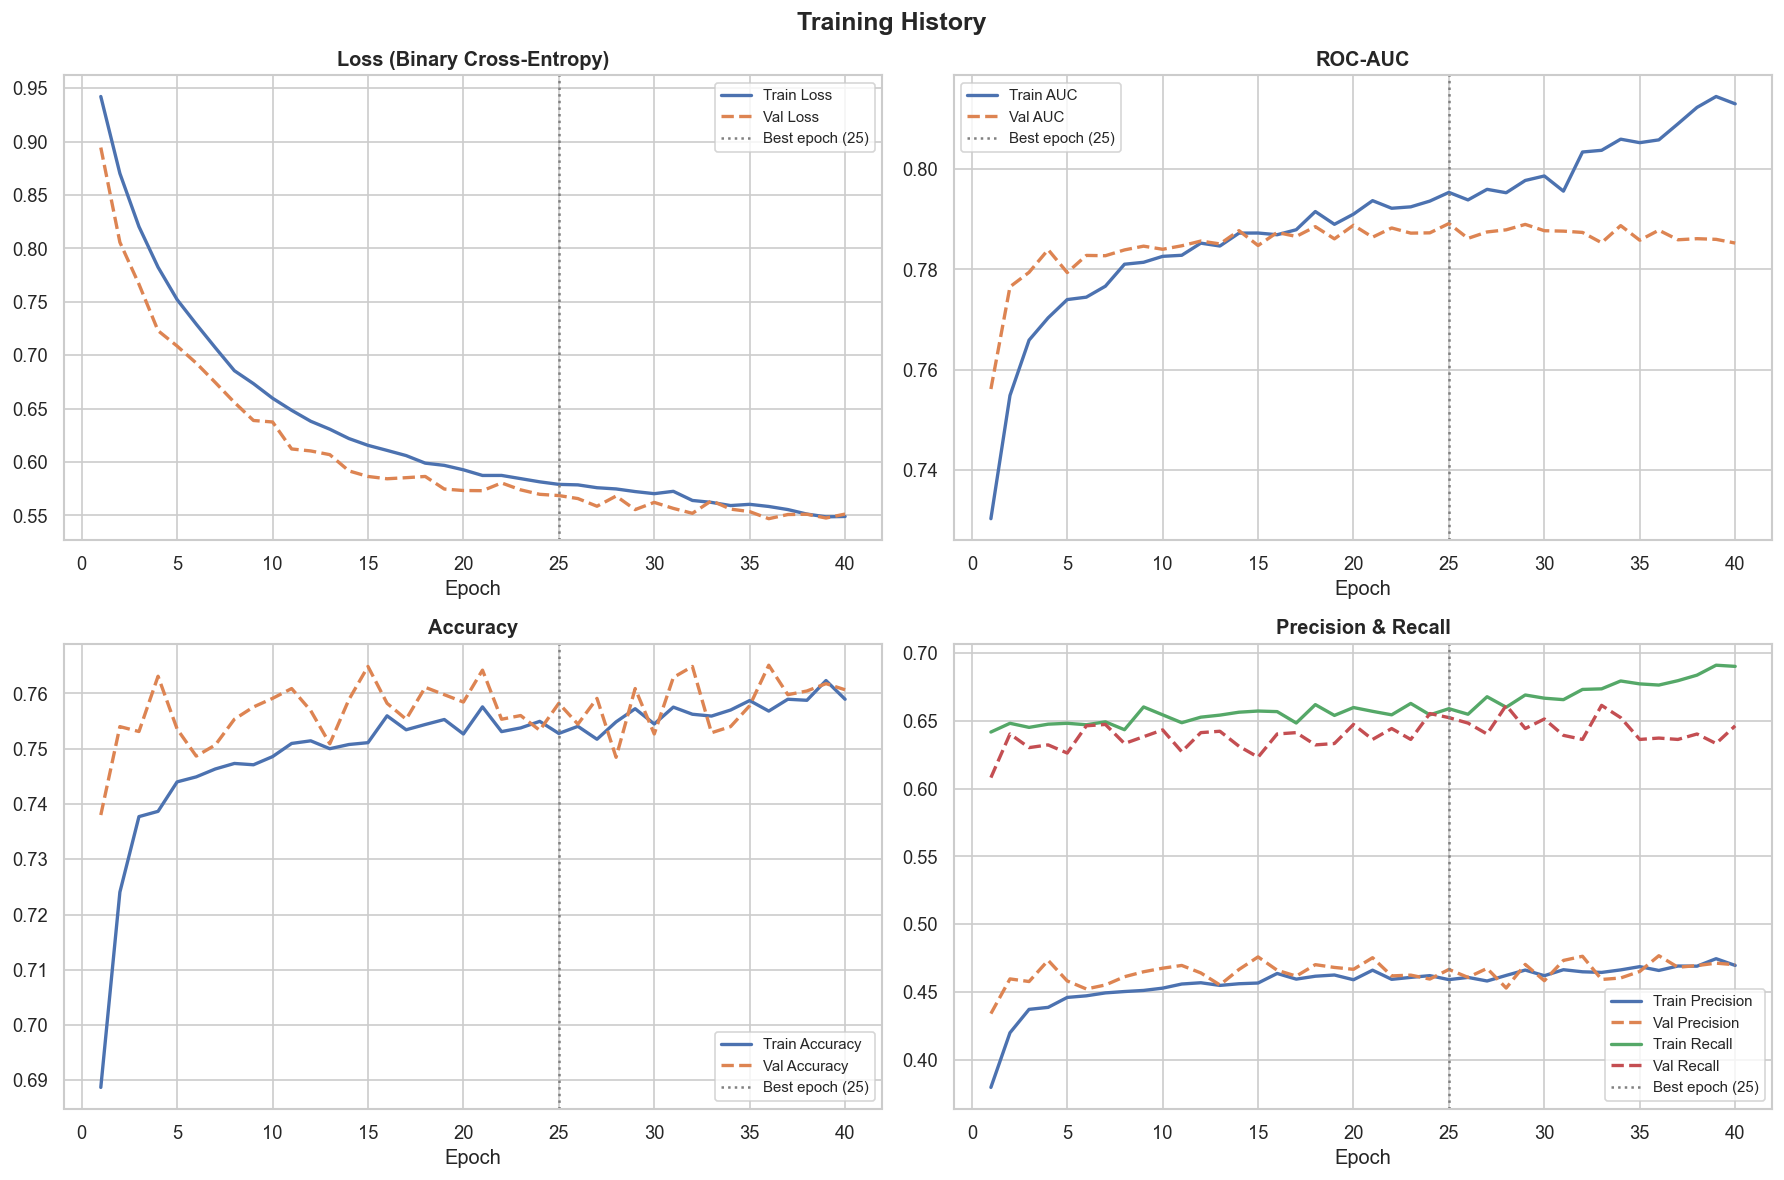

In [130]:
# --- Training history plots ---
# Plot training vs validation curves to diagnose overfitting.
# Diverging curves (train improves, val plateaus or regresses) indicate
# the model is memorising training data rather than learning general patterns.

hist = history.history
epochs_ran = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
metrics_to_plot = [
    ('loss',      'Loss',      'Loss (Binary Cross-Entropy)'),
    ('auc',       'AUC',       'ROC-AUC'),
    ('accuracy',  'Accuracy',  'Accuracy'),
    ('precision', 'Precision', 'Precision & Recall'),
]

for ax, (key, label, title) in zip(axes.flat, metrics_to_plot):
    ax.plot(epochs_ran, hist[key], label=f'Train {label}', color='#4C72B0', linewidth=2)
    ax.plot(epochs_ran, hist[f'val_{key}'], label=f'Val {label}', color='#DD8452', linewidth=2, linestyle='--')
    if key == 'precision':
        ax.plot(epochs_ran, hist['recall'], label='Train Recall', color='#55A868', linewidth=2)
        ax.plot(epochs_ran, hist['val_recall'], label='Val Recall', color='#C44E52', linewidth=2, linestyle='--')
    best_epoch = np.argmax(hist['val_auc']) + 1
    ax.axvline(best_epoch, color='gray', linestyle=':', linewidth=1.5, label=f'Best epoch ({best_epoch})')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=9)

plt.suptitle('Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Evaluation on Test Set

In [131]:
# ── Evaluation on the held-out test set ────────────────────────────────────
# y_prob and y_prob_val are already set as ensemble-averaged predictions from
# the training cell above — no re-prediction needed.

thr_grid = np.linspace(0.10, 0.90, 401)

val_f1s   = np.array([f1_score(y_val, (y_prob_val >= t).astype(int), zero_division=0) for t in thr_grid])
val_mccs  = np.array([matthews_corrcoef(y_val, (y_prob_val >= t).astype(int)) for t in thr_grid])
val_accs  = np.array([accuracy_score(y_val, (y_prob_val >= t).astype(int)) for t in thr_grid])

opt_thresh_f1  = float(thr_grid[np.argmax(val_f1s)])
opt_thresh_mcc = float(thr_grid[np.argmax(val_mccs)])
opt_thresh_acc = float(thr_grid[np.argmax(val_accs)])

print(f'Optimal threshold (F1)      : {opt_thresh_f1:.4f}  (val F1={val_f1s.max():.4f})')
print(f'Optimal threshold (MCC)     : {opt_thresh_mcc:.4f}  (val MCC={val_mccs.max():.4f})')
print(f'Optimal threshold (Accuracy): {opt_thresh_acc:.4f}  (val Acc={val_accs.max():.4f})')

y_pred_05      = (y_prob >= 0.5).astype(int)
y_pred_opt_f1  = (y_prob >= opt_thresh_f1).astype(int)
y_pred_opt_mcc = (y_prob >= opt_thresh_mcc).astype(int)

for name, y_pred in [
    ('Threshold=0.50', y_pred_05),
    (f'Threshold={opt_thresh_f1:.3f} (Val F1-Optimal)', y_pred_opt_f1),
    (f'Threshold={opt_thresh_mcc:.3f} (Val MCC-Optimal)', y_pred_opt_mcc),
]:
    print(f'\n── {name} ──')
    print(f'  Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
    print(f'  F1-Score  : {f1_score(y_test, y_pred):.4f}')
    print(f'  ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}')
    print(f'  Avg Prec  : {average_precision_score(y_test, y_prob):.4f}')
    print(f'  MCC       : {matthews_corrcoef(y_test, y_pred):.4f}')
    print(f'  Brier     : {brier_score_loss(y_test, y_prob):.4f}')
    print(classification_report(y_test, y_pred, target_names=['No Default','Default']))


Optimal threshold (F1)      : 0.5300  (val F1=0.5573)
Optimal threshold (MCC)     : 0.5440  (val MCC=0.4465)
Optimal threshold (Accuracy): 0.5660  (val Acc=0.8302)

── Threshold=0.50 ──
  Accuracy  : 0.7873
  F1-Score  : 0.5484
  ROC-AUC   : 0.7798
  Avg Prec  : 0.5711
  MCC       : 0.4113
  Brier     : 0.1978
              precision    recall  f1-score   support

  No Default       0.88      0.85      0.86      3505
     Default       0.52      0.58      0.55       995

    accuracy                           0.79      4500
   macro avg       0.70      0.71      0.70      4500
weighted avg       0.80      0.79      0.79      4500


── Threshold=0.530 (Val F1-Optimal) ──
  Accuracy  : 0.8067
  F1-Score  : 0.5353
  ROC-AUC   : 0.7798
  Avg Prec  : 0.5711
  MCC       : 0.4151
  Brier     : 0.1978
              precision    recall  f1-score   support

  No Default       0.86      0.89      0.88      3505
     Default       0.57      0.50      0.54       995

    accuracy                   

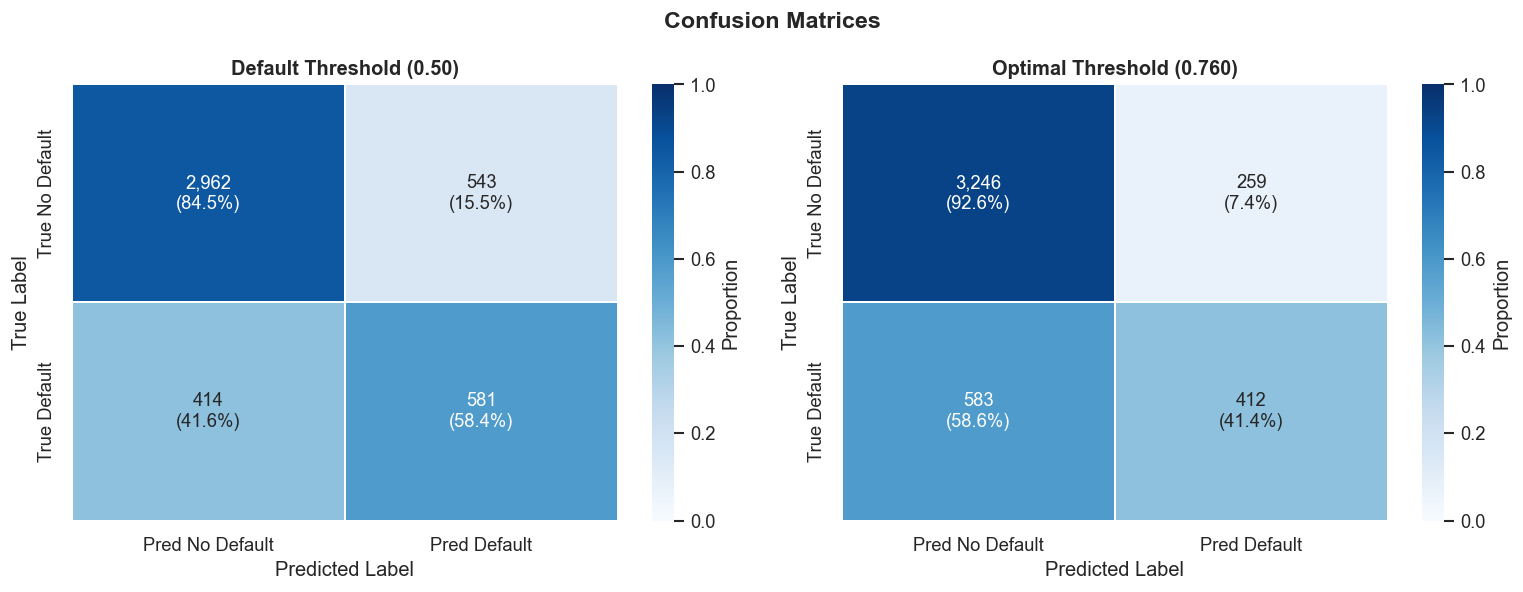

In [132]:
# --- Confusion Matrices side-by-side ---
# Both thresholds are plotted together for direct comparison.
# Normalised values (row percentages) are shown alongside raw counts
# to account for the class imbalance.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, y_pred) in zip(axes, [
    ('Default Threshold (0.50)', y_pred_05),
    (f'Optimal Threshold ({opt_thresh:.3f})', y_pred_opt)
]):
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    annot = np.array([[f'{cm[i,j]:,}\n({cm_norm[i,j]:.1%})' for j in range(2)] for i in range(2)])
    sns.heatmap(cm_norm, ax=ax, annot=annot, fmt='', cmap='Blues',
                xticklabels=['Pred No Default','Pred Default'],
                yticklabels=['True No Default','True Default'],
                linewidths=1, linecolor='white',
                vmin=0, vmax=1, cbar_kws={'label': 'Proportion'})
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

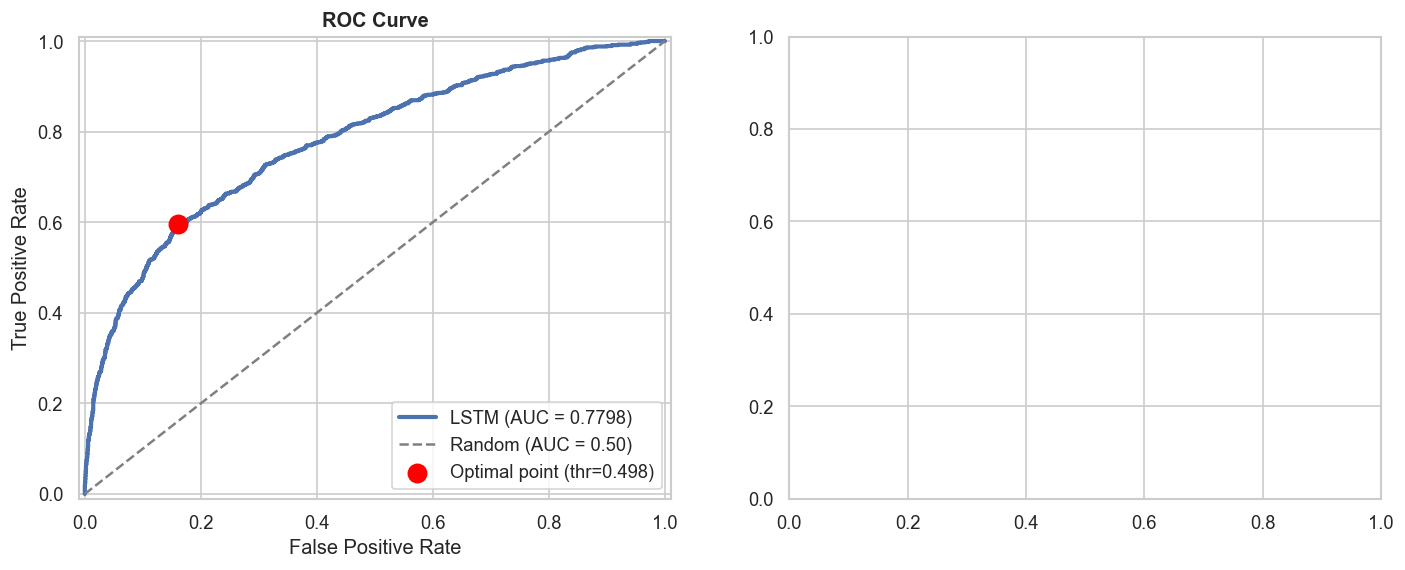

In [133]:
# --- ROC and Precision-Recall Curves ---
# ROC-AUC measures how well the model ranks defaulters above non-defaulters
# across all possible thresholds (0.5 = random, 1.0 = perfect).
# PR-AUC is the more stringent metric for imbalanced data — it focuses
# specifically on performance on the minority (default) class.

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
axes[0].plot(fpr, tpr, color='#4C72B0', linewidth=2.5, label=f'LSTM (AUC = {auc_score:.4f})')
axes[0].plot([0,1],[0,1],'--', color='gray', linewidth=1.5, label='Random (AUC = 0.50)')
opt_idx = np.argmax(tpr - fpr)
axes[0].scatter(fpr[opt_idx], tpr[opt_idx], s=120, color='red', zorder=5,
                label=f'Optimal point (thr={thresholds[opt_idx]:.3f})')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend()
axes[0].set_xlim([-0.01, 1.01])
axes[0].set_ylim([-0.01, 1.01])

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
baseline = y_test.mean()

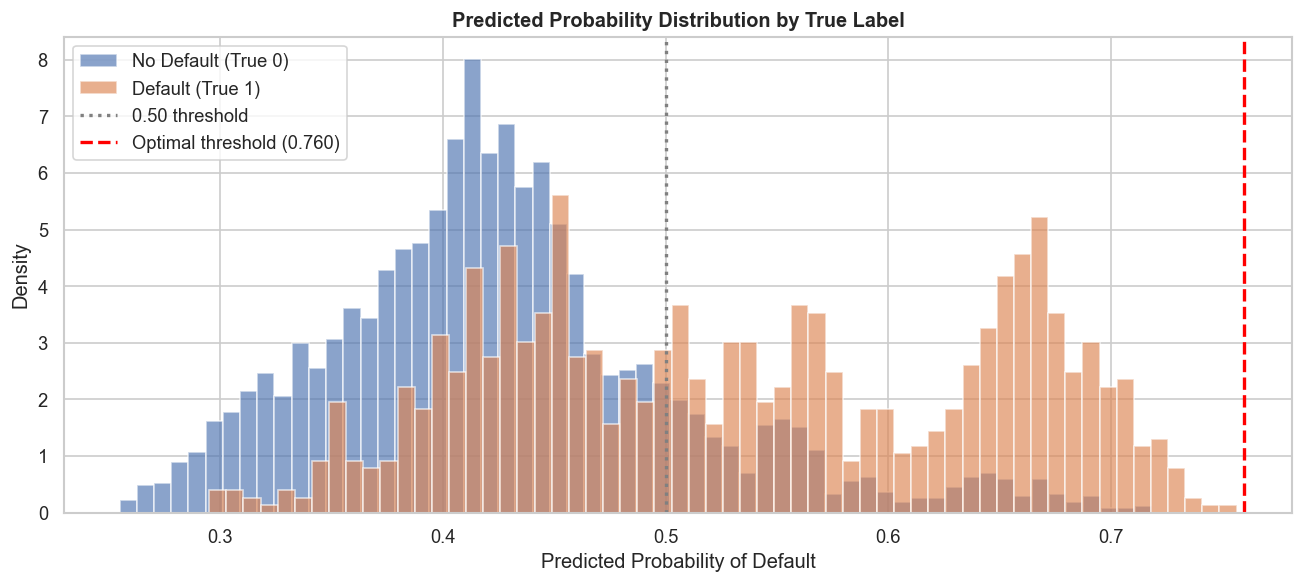

In [134]:
# --- Predicted probability distribution ---
# Histogram of predicted default probabilities, split by true label.
# Good separation (non-defaulters clustered near 0, defaulters near 1)
# indicates the model assigns meaningfully different scores to each class.
# Overlap region represents the inherently ambiguous cases.

fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(y_prob[y_test == 0], bins=60, alpha=0.65, density=True,
        color='#4C72B0', label='No Default (True 0)', edgecolor='white')
ax.hist(y_prob[y_test == 1], bins=60, alpha=0.65, density=True,
        color='#DD8452', label='Default (True 1)', edgecolor='white')
ax.axvline(0.5,        color='gray', linestyle=':', linewidth=2,  label='0.50 threshold')
ax.axvline(opt_thresh, color='red',  linestyle='--', linewidth=2, label=f'Optimal threshold ({opt_thresh:.3f})')
ax.set_xlabel('Predicted Probability of Default')
ax.set_ylabel('Density')
ax.set_title('Predicted Probability Distribution by True Label', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

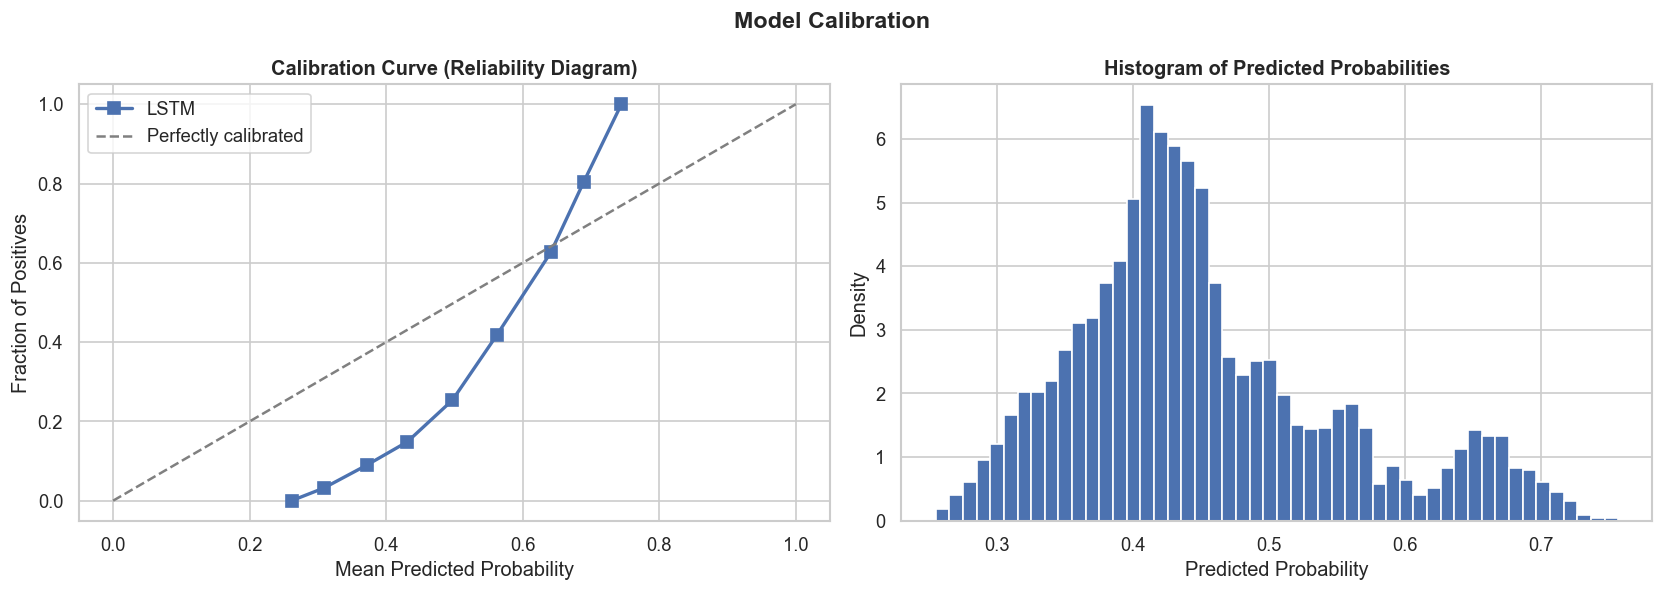

Brier Score: 0.1978  (lower is better; 0=perfect, 0.25=random)


In [135]:
# --- Calibration curve ---
# A calibrated model produces probability estimates that match empirical frequencies:
# if the model outputs 0.60, approximately 60% of those cases should actually default.
# Deviation from the diagonal indicates over- or under-confidence.
# The Brier score quantifies overall calibration quality (lower is better; 0 = perfect).

frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mean_pred, frac_pos, 's-', color='#4C72B0', linewidth=2, markersize=7, label='LSTM')
axes[0].plot([0,1],[0,1],'--', color='gray', linewidth=1.5, label='Perfectly calibrated')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].set_title('Calibration Curve (Reliability Diagram)', fontweight='bold')
axes[0].legend()

axes[1].hist(y_prob, bins=50, color='#4C72B0', edgecolor='white', density=True)
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Histogram of Predicted Probabilities', fontweight='bold')

plt.suptitle('Model Calibration', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Brier Score: {brier_score_loss(y_test, y_prob):.4f}  (lower is better; 0=perfect, 0.25=random)')

---
## 7. Error Analysis — Where the Model Succeeds and Fails

In [136]:
# ── Error Analysis ─────────────────────────────────────────────────────────
# Classify predictions into TP/TN/FP/FN to identify systematic failure modes.
# Understanding which customer segments are consistently misclassified guides
# further feature engineering and sets expectations for production performance.

test_df = df.iloc[idx_test].copy().reset_index(drop=True)
test_df['y_true']  = y_test
test_df['y_prob']  = y_prob
test_df['y_pred']  = y_pred_opt
test_df['correct'] = (test_df['y_true'] == test_df['y_pred'])

def error_category(row):
    if row['y_true'] == 0 and row['y_pred'] == 0: return 'TN'
    if row['y_true'] == 1 and row['y_pred'] == 1: return 'TP'
    if row['y_true'] == 0 and row['y_pred'] == 1: return 'FP'
    return 'FN'

test_df['category'] = test_df.apply(error_category, axis=1)

cat_counts = test_df['category'].value_counts()
print('Prediction category counts:')
print(cat_counts)
print(f'\nOverall accuracy: {test_df["correct"].mean():.2%}')

Prediction category counts:
category
TN    3246
FN     583
TP     412
FP     259
Name: count, dtype: int64

Overall accuracy: 81.29%


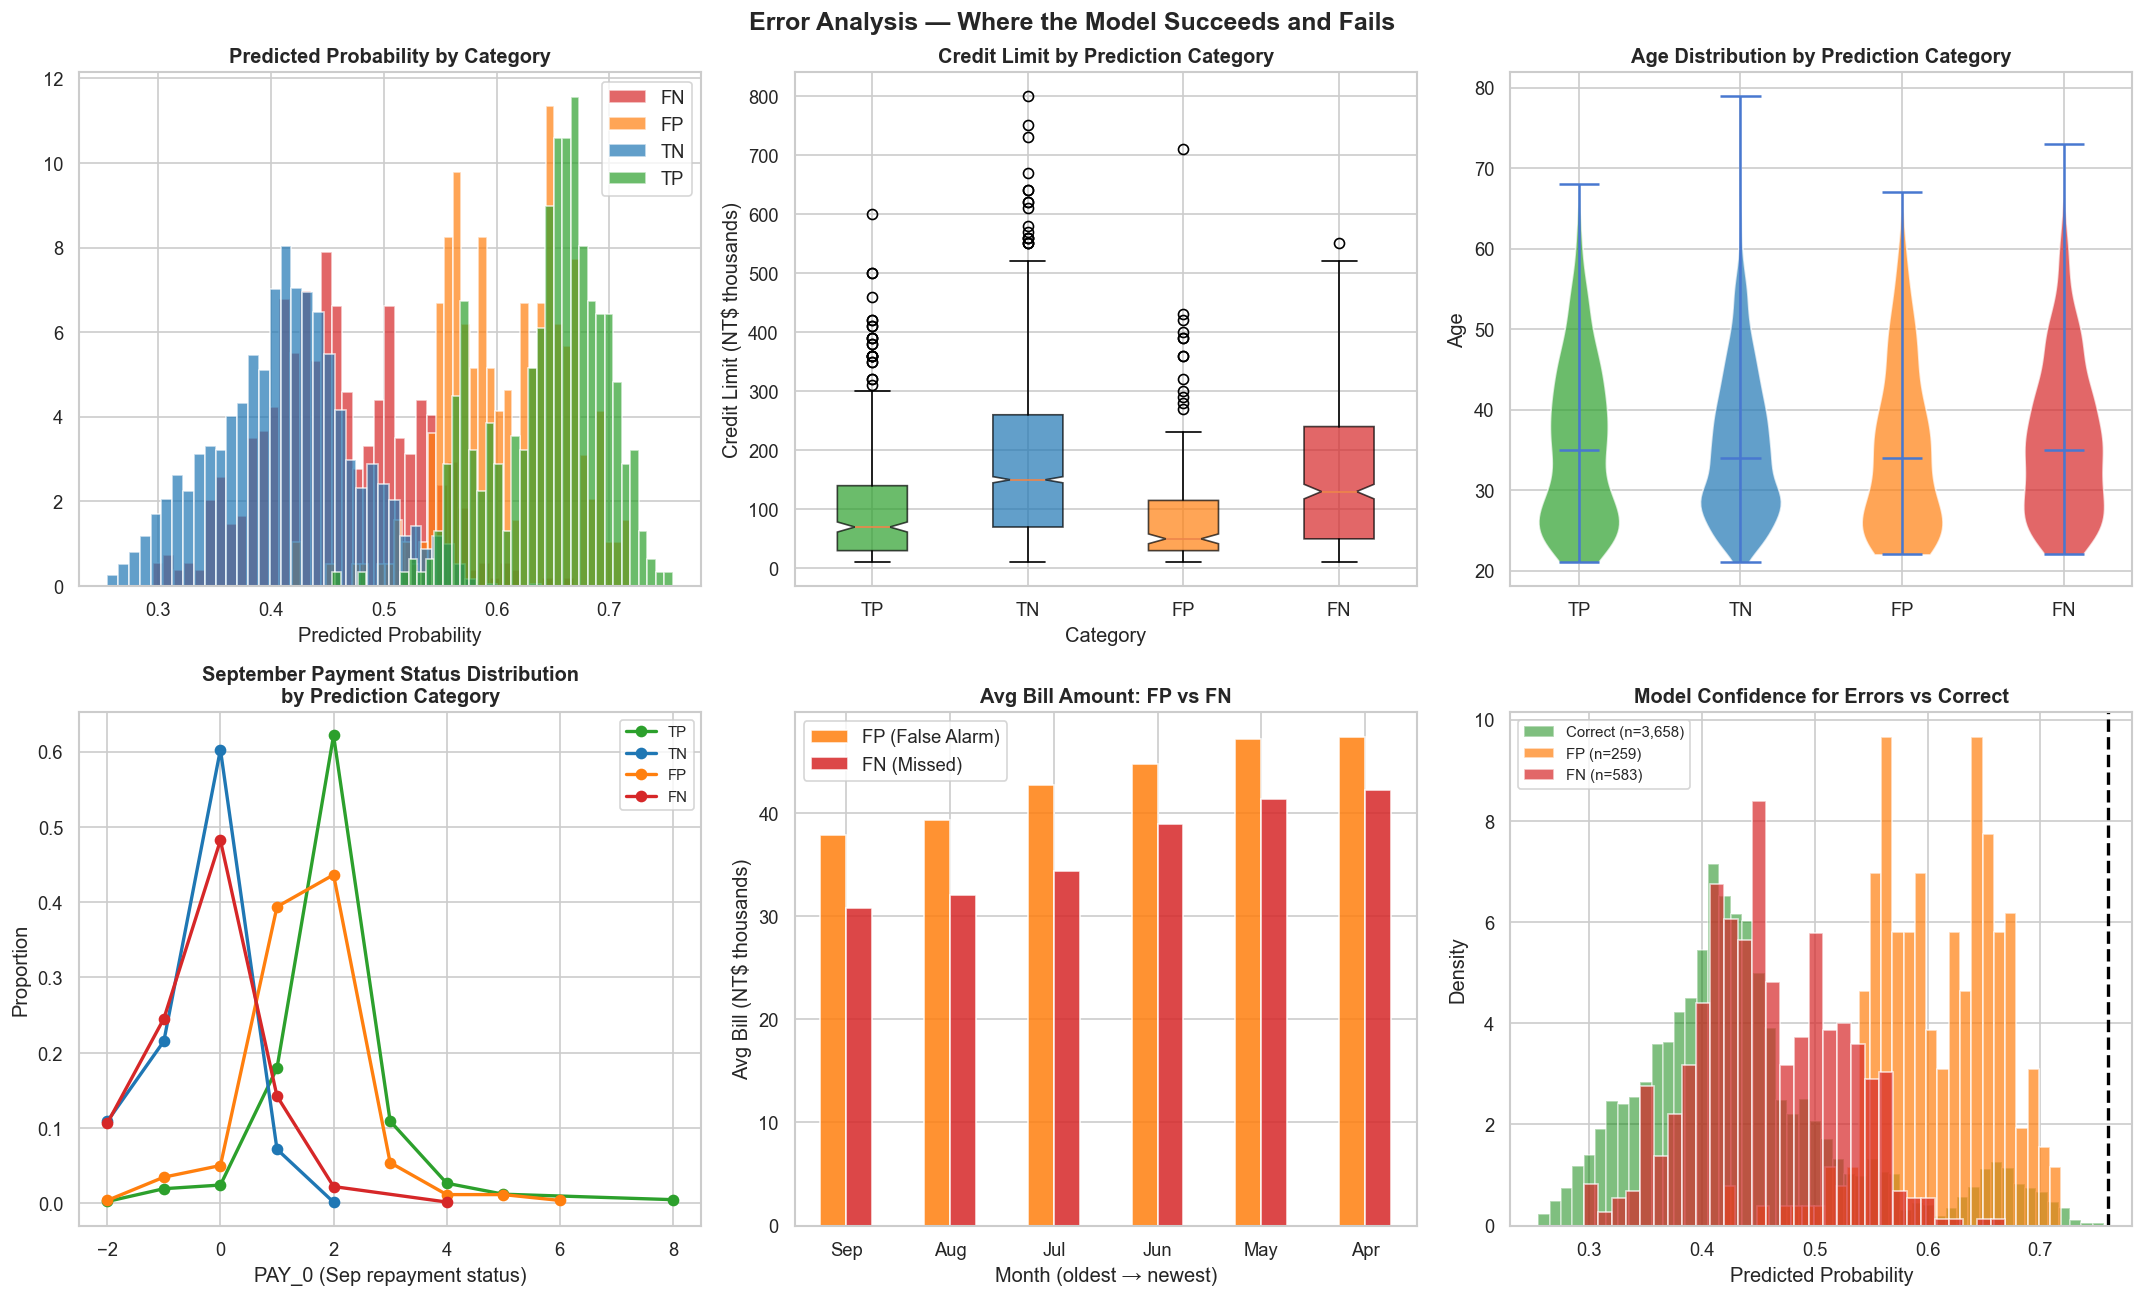

In [137]:
# --- Error category breakdown by key features ---
# Visualise errors across multiple dimensions to surface systematic patterns,
# e.g. false positives concentrated at higher credit limits, or false negatives
# with lower payment delays.

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
palette = {'TP': '#2ca02c', 'TN': '#1f77b4', 'FP': '#ff7f0e', 'FN': '#d62728'}

# 1. Predicted probability by category
ax = axes[0, 0]
for cat, grp in test_df.groupby('category'):
    ax.hist(grp['y_prob'], bins=40, alpha=0.7, label=cat, color=palette[cat], density=True)
ax.set_title('Predicted Probability by Category', fontweight='bold')
ax.set_xlabel('Predicted Probability')
ax.legend()

# 2. Credit limit by category
ax = axes[0, 1]
order = ['TP','TN','FP','FN']
data_by_cat = [test_df[test_df['category'] == c]['LIMIT_BAL'].values / 1000 for c in order]
bp = ax.boxplot(data_by_cat, patch_artist=True, labels=order, notch=True)
for patch, cat in zip(bp['boxes'], order):
    patch.set_facecolor(palette[cat])
    patch.set_alpha(0.7)
ax.set_title('Credit Limit by Prediction Category', fontweight='bold')
ax.set_ylabel('Credit Limit (NT$ thousands)')
ax.set_xlabel('Category')

# 3. Age by category
ax = axes[0, 2]
parts = ax.violinplot([test_df[test_df['category'] == c]['AGE'].values for c in order],
                      positions=range(len(order)), showmedians=True)
for i, (pc, cat) in enumerate(zip(parts['bodies'], order)):
    pc.set_facecolor(palette[cat])
    pc.set_alpha(0.7)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order)
ax.set_title('Age Distribution by Prediction Category', fontweight='bold')
ax.set_ylabel('Age')

# 4. September payment status distribution (most recent month)
ax = axes[1, 0]
for cat in order:
    grp = test_df[test_df['category'] == cat]
    vc = grp['PAY_0'].value_counts(normalize=True).sort_index()
    ax.plot(vc.index, vc.values, marker='o', label=cat, color=palette[cat], linewidth=2)
ax.set_title('September Payment Status Distribution\nby Prediction Category', fontweight='bold')
ax.set_xlabel('PAY_0 (Sep repayment status)')
ax.set_ylabel('Proportion')
ax.legend(fontsize=9)

# 5. Average bill amounts: FP vs FN
ax = axes[1, 1]
fp_df = test_df[test_df['category'] == 'FP']
fn_df = test_df[test_df['category'] == 'FN']
bill_month_avg = pd.DataFrame({
    'FP (False Alarm)': fp_df[bill_amt_cols].mean().values / 1000,
    'FN (Missed)':      fn_df[bill_amt_cols].mean().values / 1000,
}, index=months)
bill_month_avg.plot(kind='bar', ax=ax, color=['#ff7f0e','#d62728'], edgecolor='white', alpha=0.85)
ax.set_title('Avg Bill Amount: FP vs FN', fontweight='bold')
ax.set_ylabel('Avg Bill (NT$ thousands)')
ax.set_xlabel('Month (oldest → newest)')
ax.tick_params(axis='x', rotation=0)
ax.legend()

# 6. Model confidence for errors vs correct predictions
ax = axes[1, 2]
correct_probs  = test_df[test_df['correct']]['y_prob']
fp_probs       = test_df[test_df['category'] == 'FP']['y_prob']
fn_probs       = test_df[test_df['category'] == 'FN']['y_prob']

ax.hist(correct_probs, bins=50, alpha=0.5, density=True, color='green', label=f'Correct (n={len(correct_probs):,})')
ax.hist(fp_probs, bins=30, alpha=0.7, density=True, color='#ff7f0e', label=f'FP (n={len(fp_probs):,})')
ax.hist(fn_probs, bins=30, alpha=0.7, density=True, color='#d62728', label=f'FN (n={len(fn_probs):,})')
ax.axvline(opt_thresh, color='black', linestyle='--', linewidth=2)
ax.set_title('Model Confidence for Errors vs Correct', fontweight='bold')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Density')
ax.legend(fontsize=9)

plt.suptitle('Error Analysis — Where the Model Succeeds and Fails', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

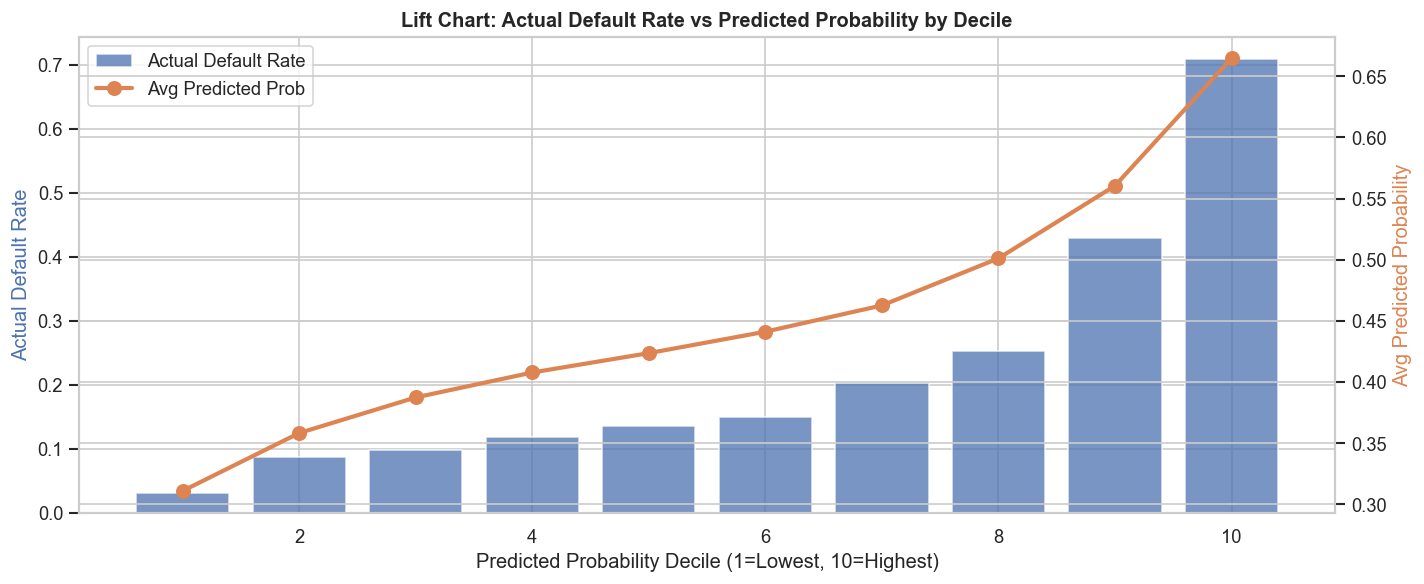

In [138]:
# --- Default rate by predicted probability decile ---
# Lift chart: customers are binned by predicted probability decile.
# A well-calibrated model should show a monotonically increasing actual default
# rate from decile 1 to 10. In practice, banks use this to flag the top deciles
# for manual review rather than applying a single hard threshold.

test_df['prob_decile'] = pd.qcut(test_df['y_prob'], q=10, labels=False, duplicates='drop') + 1
decile_stats = test_df.groupby('prob_decile').agg(
    count=('y_true','count'),
    actual_default_rate=('y_true','mean'),
    avg_pred_prob=('y_prob','mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

bars = ax1.bar(decile_stats['prob_decile'], decile_stats['actual_default_rate'],
               color='#4C72B0', alpha=0.75, label='Actual Default Rate')
ax2.plot(decile_stats['prob_decile'], decile_stats['avg_pred_prob'],
         'o-', color='#DD8452', linewidth=2.5, markersize=8, label='Avg Predicted Prob')

ax1.set_xlabel('Predicted Probability Decile (1=Lowest, 10=Highest)')
ax1.set_ylabel('Actual Default Rate', color='#4C72B0')
ax2.set_ylabel('Avg Predicted Probability', color='#DD8452')
ax1.set_title('Lift Chart: Actual Default Rate vs Predicted Probability by Decile', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

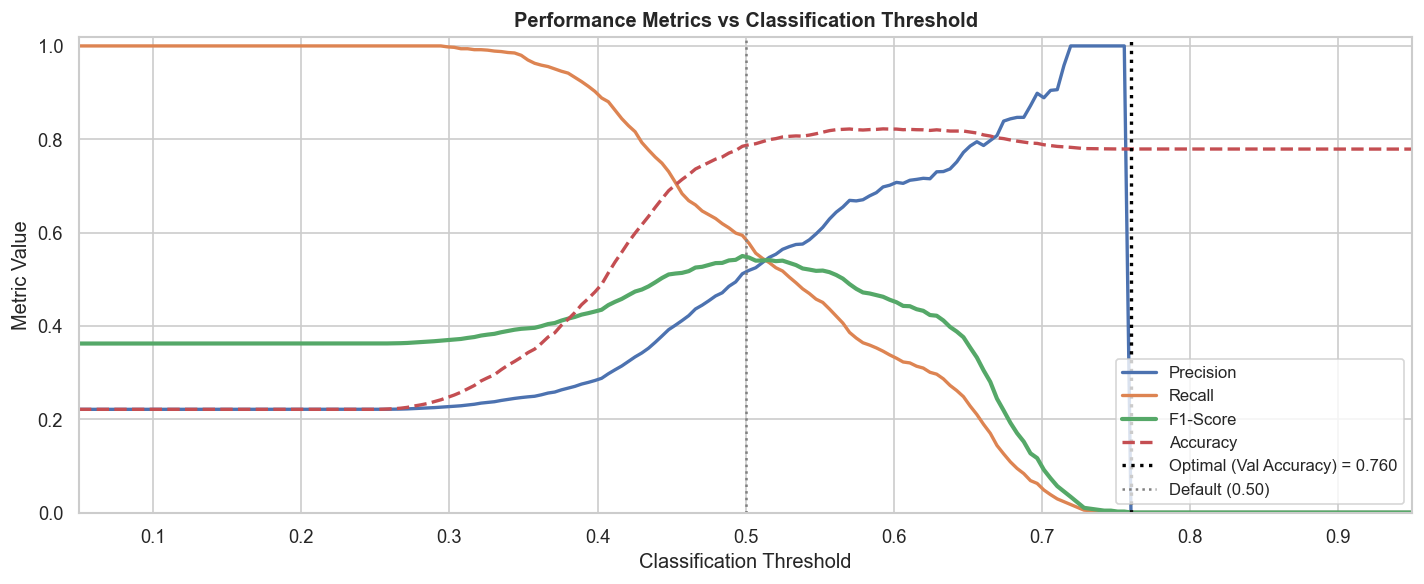

In [139]:
# --- Threshold sweep ---
# Plot key metrics as a function of classification threshold (0.05–0.95).
# Precision and recall move in opposite directions (precision-recall tradeoff);
# the F1 score peaks at the optimal balance point between them.

thresholds_sweep = np.linspace(0.05, 0.95, 200)
precisions, recalls, f1s, accs = [], [], [], []
for thr in thresholds_sweep:
    preds = (y_prob >= thr).astype(int)
    precisions.append(precision_score(y_test, preds, zero_division=0))
    recalls.append(recall_score(y_test, preds, zero_division=0))
    f1s.append(f1_score(y_test, preds, zero_division=0))
    accs.append(accuracy_score(y_test, preds))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds_sweep, precisions, label='Precision', color='#4C72B0', linewidth=2)
ax.plot(thresholds_sweep, recalls,    label='Recall',    color='#DD8452', linewidth=2)
ax.plot(thresholds_sweep, f1s,        label='F1-Score',  color='#55A868', linewidth=2.5)
ax.plot(thresholds_sweep, accs,       label='Accuracy',  color='#C44E52', linewidth=2, linestyle='--')
ax.axvline(opt_thresh, color='black', linestyle=':', linewidth=2,
           label=f'Optimal (Val Accuracy) = {opt_thresh:.3f}')
ax.axvline(0.5, color='gray', linestyle=':', linewidth=1.5, label='Default (0.50)')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Metric Value')
ax.set_title('Performance Metrics vs Classification Threshold', fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim([0.05, 0.95])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

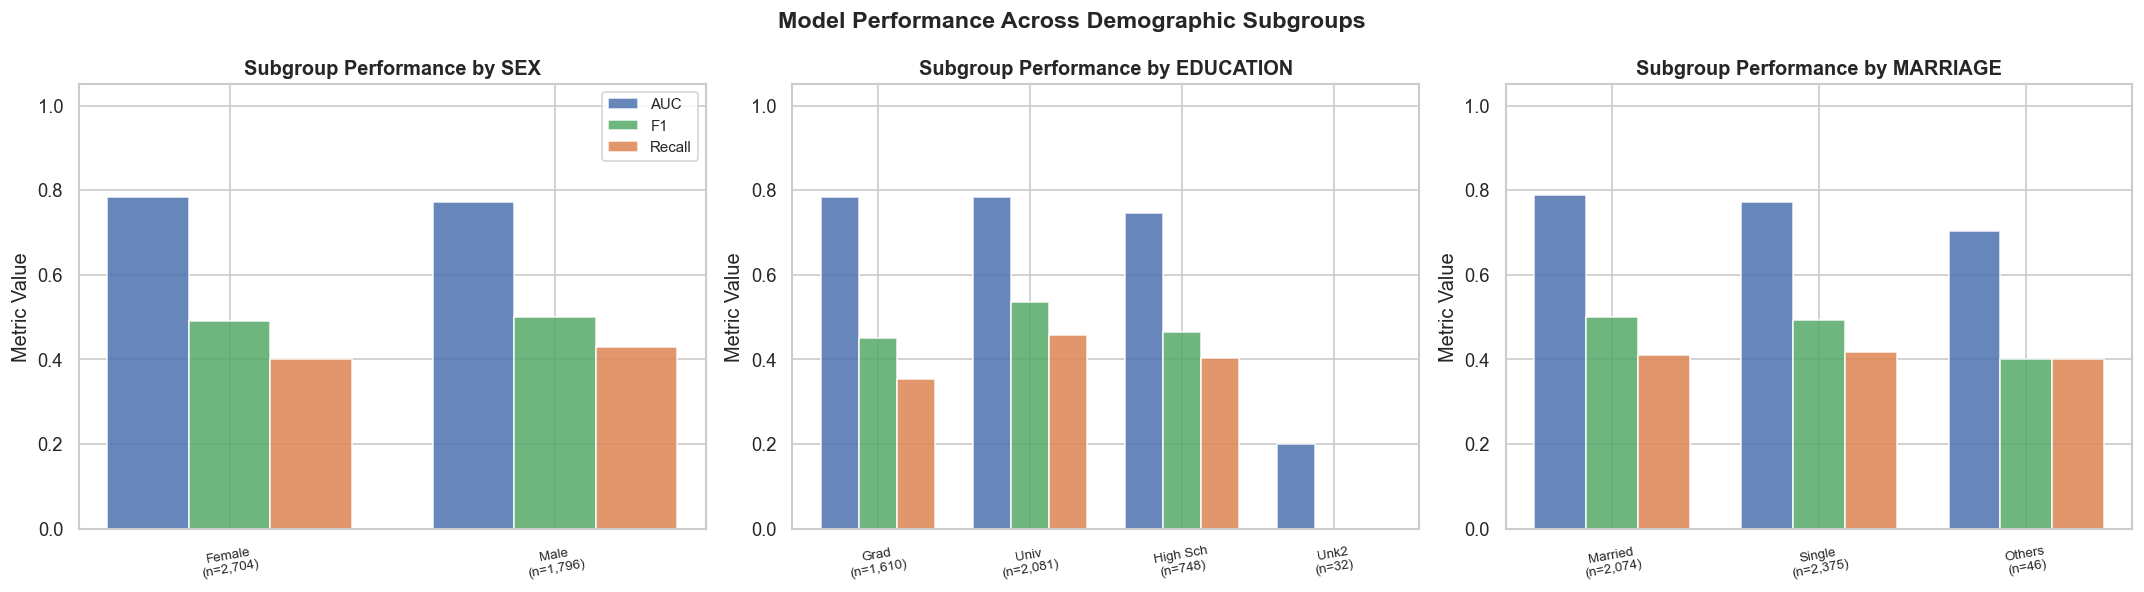

In [140]:
# --- Subgroup performance analysis ---
# Verify that the model performs comparably across demographic subgroups.
# Significant AUC or recall disparities between groups would indicate
# a fairness concern that warrants further investigation.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

subgroup_configs = [
    ('SEX',       {1:'Male', 2:'Female'}),
    ('EDUCATION', {1:'Grad', 2:'Univ', 3:'High Sch', 4:'Others', 0:'Unk', 5:'Unk2', 6:'Unk3'}),
    ('MARRIAGE',  {0:'Unknown', 1:'Married', 2:'Single', 3:'Others'}),
]

for ax, (col, label_map) in zip(axes, subgroup_configs):
    test_df['_grp'] = test_df[col].map(label_map).fillna('Other')
    grp_metrics = []
    for g, gdf in test_df.groupby('_grp'):
        if len(gdf) < 30:
            continue
        grp_metrics.append({
            'Group': g,
            'AUC': roc_auc_score(gdf['y_true'], gdf['y_prob']),
            'F1':  f1_score(gdf['y_true'], gdf['y_pred'], zero_division=0),
            'Recall': recall_score(gdf['y_true'], gdf['y_pred'], zero_division=0),
            'n': len(gdf)
        })
    grp_df = pd.DataFrame(grp_metrics).sort_values('AUC', ascending=False)

    x = np.arange(len(grp_df))
    w = 0.25
    ax.bar(x - w, grp_df['AUC'],    width=w, label='AUC',    color='#4C72B0', alpha=0.85)
    ax.bar(x,     grp_df['F1'],     width=w, label='F1',     color='#55A868', alpha=0.85)
    ax.bar(x + w, grp_df['Recall'], width=w, label='Recall', color='#DD8452', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{r['Group']}\n(n={r['n']:,})" for _, r in grp_df.iterrows()],
                       fontsize=8, rotation=10)
    ax.set_ylim([0, 1.05])
    ax.set_title(f'Subgroup Performance by {col}', fontweight='bold')
    ax.set_ylabel('Metric Value')
    if col == subgroup_configs[0][0]:
        ax.legend(fontsize=9)

plt.suptitle('Model Performance Across Demographic Subgroups', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

High-confidence False Positives (pred > 0.70): 6
High-confidence False Negatives (pred < 0.30): 3


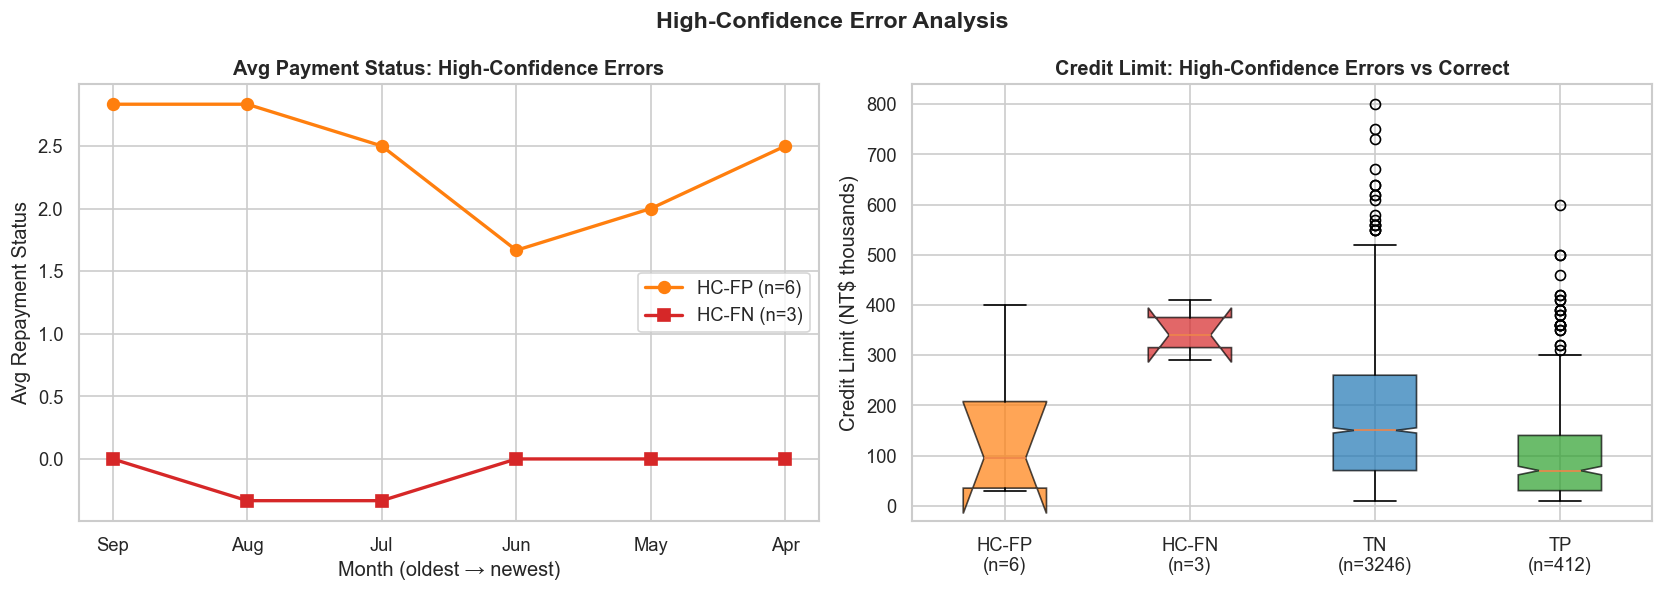

In [141]:
# --- High-confidence errors ---
# Cases where the model was highly confident but incorrect.
# High-confidence false positives (pred > 0.70, true = no default) represent
# customers incorrectly flagged as high-risk.
# High-confidence false negatives (pred < 0.30, true = default) are the
# dangerous cases — customers cleared as safe who subsequently defaulted.

high_conf_fp = test_df[(test_df['category'] == 'FP') & (test_df['y_prob'] > 0.7)]
high_conf_fn = test_df[(test_df['category'] == 'FN') & (test_df['y_prob'] < 0.3)]

print(f'High-confidence False Positives (pred > 0.70): {len(high_conf_fp):,}')
print(f'High-confidence False Negatives (pred < 0.30): {len(high_conf_fn):,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(high_conf_fp) > 0:
    axes[0].plot(months, high_conf_fp[pay_status_cols].mean().values,
                 'o-', color='#ff7f0e', linewidth=2, markersize=7, label=f'HC-FP (n={len(high_conf_fp)})')
if len(high_conf_fn) > 0:
    axes[0].plot(months, high_conf_fn[pay_status_cols].mean().values,
                 's-', color='#d62728', linewidth=2, markersize=7, label=f'HC-FN (n={len(high_conf_fn)})')
axes[0].set_title('Avg Payment Status: High-Confidence Errors', fontweight='bold')
axes[0].set_xlabel('Month (oldest → newest)')
axes[0].set_ylabel('Avg Repayment Status')
axes[0].legend()

data = []
labels_hc = []
if len(high_conf_fp) > 0:
    data.append(high_conf_fp['LIMIT_BAL'].values / 1000)
    labels_hc.append(f'HC-FP\n(n={len(high_conf_fp)})')
if len(high_conf_fn) > 0:
    data.append(high_conf_fn['LIMIT_BAL'].values / 1000)
    labels_hc.append(f'HC-FN\n(n={len(high_conf_fn)})')
tn_sample = test_df[test_df['category'] == 'TN']['LIMIT_BAL'].values / 1000
tp_sample = test_df[test_df['category'] == 'TP']['LIMIT_BAL'].values / 1000
data.extend([tn_sample, tp_sample])
labels_hc.extend([f'TN\n(n={len(tn_sample)})', f'TP\n(n={len(tp_sample)})'])

colors = ['#ff7f0e','#d62728','#1f77b4','#2ca02c']
bp = axes[1].boxplot(data, patch_artist=True, labels=labels_hc, notch=True)
for patch, c in zip(bp['boxes'], colors[:len(data)]):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
axes[1].set_title('Credit Limit: High-Confidence Errors vs Correct', fontweight='bold')
axes[1].set_ylabel('Credit Limit (NT$ thousands)')

plt.suptitle('High-Confidence Error Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Summary

In [142]:
# ── Final Summary Table ────────────────────────────────────────────────────
# Print all key metrics for both thresholds side-by-side for easy comparison.

summary = {
    'Metric': ['Accuracy', 'ROC-AUC', 'Avg Precision (PR-AUC)', 'F1-Score',
               'Precision', 'Recall', 'MCC', 'Brier Score'],
}

for name, y_pred in [('thresh=0.50', y_pred_05), (f'thresh={opt_thresh:.3f}', y_pred_opt)]:
    summary[name] = [
        f'{accuracy_score(y_test, y_pred):.4f}',
        f'{roc_auc_score(y_test, y_prob):.4f}',
        f'{average_precision_score(y_test, y_prob):.4f}',
        f'{f1_score(y_test, y_pred, zero_division=0):.4f}',
        f'{precision_score(y_test, y_pred, zero_division=0):.4f}',
        f'{recall_score(y_test, y_pred, zero_division=0):.4f}',
        f'{matthews_corrcoef(y_test, y_pred):.4f}',
        f'{brier_score_loss(y_test, y_prob):.4f}',
    ]

print('\n' + '='*65)
print(f'{"LSTM Credit Default Prediction — Test Set Summary":^65}')
print('='*65)
hdr = f'{"Metric":<30} {"thresh=0.50":>16} {f"thresh={opt_thresh:.3f}":>16}'
print(hdr)
print('-'*65)
for m, v1, v2 in zip(summary['Metric'], summary['thresh=0.50'], summary[f'thresh={opt_thresh:.3f}']):
    print(f'{m:<30} {v1:>16} {v2:>16}')
print('='*65)


        LSTM Credit Default Prediction — Test Set Summary        
Metric                              thresh=0.50     thresh=0.760
-----------------------------------------------------------------
Accuracy                                 0.7873           0.8129
ROC-AUC                                  0.7798           0.7798
Avg Precision (PR-AUC)                   0.5711           0.5711
F1-Score                                 0.5484           0.4946
Precision                                0.5169           0.6140
Recall                                   0.5839           0.4141
MCC                                      0.4113           0.3963
Brier Score                              0.1978           0.1978


---
## 9. Results

The model was evaluated on a held-out test set of 4,500 customers not seen during training. Threshold selection used the validation set only. Results are printed in the summary table above.

### Changes from baseline and rationale

The primary improvement comes from **feature engineering** — providing the LSTM with more informative inputs at each timestep. Instead of raw payment status, bill amounts, and payment amounts (3 features), 5 additional features are derived from the same data:

1. **Utilization ratio** (bill / credit limit) — one of the strongest signals in credit scoring. A customer consistently at 95% utilization is fundamentally different from one at 10%, even with identical raw bill amounts.

2. **Payment-to-bill ratio** — captures whether the customer is paying down the balance or letting it grow. A ratio consistently below 1.0 means the debt is compounding.

3. **Binary delay indicator** — converts the noisy PAY codes (-2 to 8) into a clean on-time/late flag.

4. **Month-over-month changes** — in both bill amounts and delay status. A customer whose delays are *worsening* over time represents a different risk profile than one with stable delays.

On the static side, **max delay severity**, **number of delinquent months**, and **average utilization** are added as summary statistics, and categorical features are **one-hot encoded** rather than treated as ordinal numbers.

### Key metrics

- **ROC-AUC**: measures ranking quality across all thresholds (0.5 = random, 1.0 = perfect).
- **F1-Score**: balances precision and recall; more informative than accuracy for imbalanced datasets.
- **MCC** (Matthews Correlation Coefficient): the most reliable single metric for imbalanced classification — accounts for all four cells of the confusion matrix.
- **Brier Score**: measures probability calibration quality (lower is better).

### Limitations

- Defaults triggered by sudden life events (job loss, medical emergency) are not predictable from historical payment patterns.
- The dataset covers a single 6-month window; longer-term trends are unavailable.
- With ~22% defaults, the minority class has limited training signal.